CISLR — L14A
PRETRAINED VIDEOMAE TRANSFER LEARNING

PyTorch : 2.14.0+cu130
Device  : cuda
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM    : 5.64 GB

[PASS] Required files exist.

FROZEN L9 SPLIT

TRAIN      : 585
VALIDATION : 211
TEST       : 211 (LOCKED)

[PASS] Zero split overlap.
[PASS] Frozen 211-class mapping loaded.

INDEXING CISLR VIDEO DIRECTORY
MP4 files: 7050

Resolved TRAIN      : 585
Resolved VALIDATION : 211

TEST paths resolved : NO
TEST videos decoded : NO

LOADING PRETRAINED VIDEOMAE

Checkpoint : MCG-NJU/videomae-base-finetuned-kinetics
Frames     : 16
Input size : 224

[PASS] DataLoaders created.

DATA SANITY CHECK

UID          : IMlXe5o44pc_1
Pixel values : (16, 3, 224, 224)
Label        : 0

[PASS] VideoMAE sample valid.


Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([211]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([211, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



VIDEOMAE MODEL

Hidden size: 768
Layers     : 12
Heads      : 12
Classes    : 211
Parameters : 86,389,459

Classifier: Linear(in_features=768, out_features=211, bias=True)

STAGE 1 — HEAD-ONLY TRAINING

Trainable parameters: 162,259

STAGE 1 TRAINING
[HEAD] Epoch 01 | Train   2.22%/  4.96% | Val   1.42%/  6.64% | Loss 5.2641 | 40.7s <-- BEST
[HEAD] Epoch 02 | Train   8.21%/ 22.74% | Val   4.74%/ 16.11% | Loss 5.0668 | 34.9s <-- BEST
[HEAD] Epoch 03 | Train  16.75%/ 43.08% | Val   8.53%/ 23.70% | Loss 4.9390 | 34.9s <-- BEST
[HEAD] Epoch 04 | Train  28.38%/ 57.61% | Val   9.00%/ 28.44% | Loss 4.8478 | 34.8s <-- BEST
[HEAD] Epoch 05 | Train  36.58%/ 70.43% | Val  11.37%/ 29.86% | Loss 4.7715 | 34.7s <-- BEST
[HEAD] Epoch 06 | Train  47.35%/ 75.21% | Val  11.85%/ 31.28% | Loss 4.7166 | 34.9s <-- BEST
[HEAD] Epoch 07 | Train  49.74%/ 82.74% | Val  17.06%/ 36.97% | Loss 4.6528 | 34.9s <-- BEST
[HEAD] Epoch 08 | Train  57.61%/ 85.30% | Val  17.06%/ 32.70% | Loss 4.6227 | 34.9s <-- BEST
[HEA

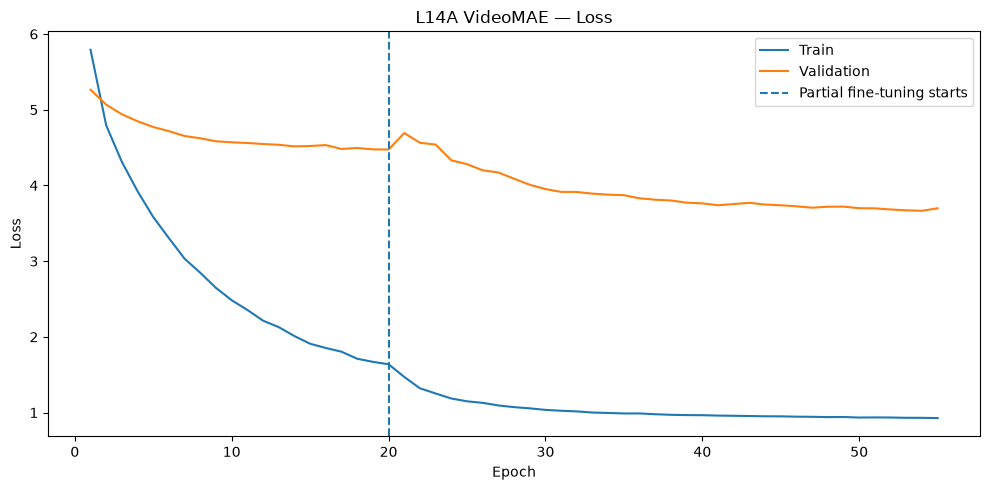

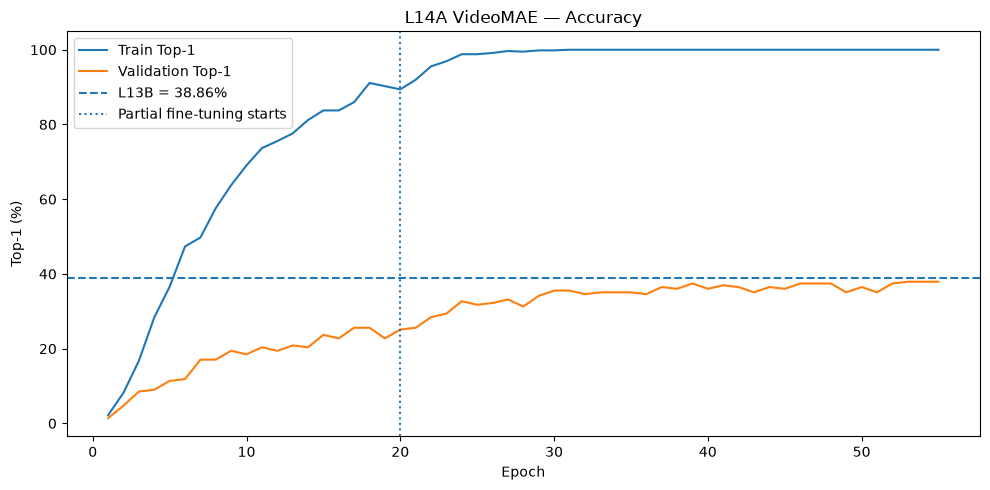


VALIDATION COMPARISON

experiment                    model  validation_top1  validation_top5
       L10                      GRU         7.109005        13.744076
       L11                   BiLSTM         8.530806        17.535545
      L12A                   ST-GCN        18.009479        27.962085
      L12B               SSL ST-GCN        28.436019        37.914692
      L13B RGB Temporal Transformer        38.862559        46.445498
      L13C        Multimodal Fusion        36.492891        44.075829
      L14A      Pretrained VideoMAE        37.914692        51.658768

L14A FINAL REPORT

PRETRAINED MODEL
--------------------------------------------------------------------------------------------------------------------------------------------
Checkpoint                 : MCG-NJU/videomae-base-finetuned-kinetics
Architecture               : VideoMAE Base
Input                      : 16 × 224 × 224
Pretrained task            : Kinetics video classification
CISLR classes         

In [1]:
# ==================================================================================================
# CISLR — L14A
# PRETRAINED VIDEOMAE TRANSFER LEARNING
#
# MCG-NJU/videomae-base-finetuned-kinetics
#
# Stage 1 : Freeze VideoMAE backbone -> train new 211-class classifier
# Stage 2 : Unfreeze final Transformer blocks -> partial fine-tuning
#
# TRAIN      : 585
# VALIDATION : 211
# TEST       : 211 — STRICTLY LOCKED
#
# ==================================================================================================

# --------------------------------------------------------------------------------------------------
# INSTALL ONCE IF NEEDED
# --------------------------------------------------------------------------------------------------
# !pip install -U transformers safetensors accelerate

import os
import cv2
import json
import time
import math
import random
import warnings

from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

warnings.filterwarnings("ignore")


# ==================================================================================================
# 0. CONFIG
# ==================================================================================================

SEED = 42

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

MODEL_ROOT = (
    PROJECT_ROOT /
    "CISLR_LANDMARK_MODEL"
)

VIDEO_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos"
)

L9_ROOT = (
    MODEL_ROOT /
    "audit/l9_split_freeze"
)

TRAIN_MANIFEST = (
    L9_ROOT /
    "splits/l9_train_manifest.csv"
)

VAL_MANIFEST = (
    L9_ROOT /
    "splits/l9_validation_manifest.csv"
)

TEST_MANIFEST = (
    L9_ROOT /
    "splits/l9_test_manifest.csv"
)

CLASS_MAPPING_PATH = (
    L9_ROOT /
    "class_mapping/l9_controlled_class_mapping.json"
)


# --------------------------------------------------------------------------------------------------
# L14A output
# --------------------------------------------------------------------------------------------------

L14A_ROOT = (
    MODEL_ROOT /
    "audit/l14_pretrained_video/l14a_videomae"
)

MODEL_DIR = L14A_ROOT / "models"
REPORT_DIR = L14A_ROOT / "reports"
PLOT_DIR = L14A_ROOT / "plots"
CACHE_DIR = L14A_ROOT / "cache"

for p in [
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR,
    CACHE_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )


# --------------------------------------------------------------------------------------------------
# VideoMAE
# --------------------------------------------------------------------------------------------------

PRETRAINED_MODEL = (
    "MCG-NJU/videomae-base-finetuned-kinetics"
)

NUM_CLASSES = 211

NUM_FRAMES = 16

IMAGE_SIZE = 224


# --------------------------------------------------------------------------------------------------
# Training
# --------------------------------------------------------------------------------------------------

BATCH_SIZE = 2

GRADIENT_ACCUMULATION = 4

NUM_WORKERS = 2

HEAD_EPOCHS = 20

FINETUNE_EPOCHS = 35

HEAD_LR = 1e-3

BACKBONE_LR = 1e-5

CLASSIFIER_LR = 1e-4

WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.10

GRAD_CLIP = 1.0

HEAD_PATIENCE = 7

FINETUNE_PATIENCE = 10

UNFREEZE_LAST_N_BLOCKS = 4


# ==================================================================================================
# 1. REPRODUCIBILITY
# ==================================================================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ==================================================================================================
# 2. DEVICE
# ==================================================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)


print("=" * 140)
print("CISLR — L14A")
print("PRETRAINED VIDEOMAE TRANSFER LEARNING")
print("=" * 140)

print()
print("PyTorch :", torch.__version__)
print("Device  :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM    :",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )


# ==================================================================================================
# 3. REQUIRED PATHS
# ==================================================================================================

required = [

    VIDEO_DIR,

    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,

    CLASS_MAPPING_PATH
]


for p in required:

    if not p.exists():

        raise FileNotFoundError(
            f"Missing: {p}"
        )


print()
print("[PASS] Required files exist.")


# ==================================================================================================
# 4. LOAD FROZEN L9 SPLIT
# ==================================================================================================

train_df = pd.read_csv(
    TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

test_df = pd.read_csv(
    TEST_MANIFEST
)


for df in [
    train_df,
    val_df,
    test_df
]:

    df["uid"] = (
        df["uid"]
        .astype(str)
    )


assert len(train_df) == 585
assert len(val_df) == 211
assert len(test_df) == 211


train_uids = set(
    train_df["uid"]
)

val_uids = set(
    val_df["uid"]
)

test_uids = set(
    test_df["uid"]
)


assert len(
    train_uids &
    val_uids
) == 0


assert len(
    train_uids &
    test_uids
) == 0


assert len(
    val_uids &
    test_uids
) == 0


print()
print("=" * 140)
print("FROZEN L9 SPLIT")
print("=" * 140)

print()
print("TRAIN      :", len(train_df))
print("VALIDATION :", len(val_df))
print("TEST       :", len(test_df), "(LOCKED)")

print()
print("[PASS] Zero split overlap.")


# ==================================================================================================
# 5. CLASS MAPPING
# ==================================================================================================

with open(
    CLASS_MAPPING_PATH,
    "r"
) as f:

    mapping_json = json.load(f)


if (
    isinstance(mapping_json, dict)
    and
    "gloss_to_id" in mapping_json
):

    gloss_to_id = {

        str(k):
        int(v)

        for k, v
        in mapping_json["gloss_to_id"].items()
    }

else:

    gloss_to_id = {

        str(k):
        int(v)

        for k, v
        in mapping_json.items()
    }


assert len(
    gloss_to_id
) == NUM_CLASSES


assert sorted(
    gloss_to_id.values()
) == list(
    range(NUM_CLASSES)
)


id_to_gloss = {

    int(v):
    str(k)

    for k, v
    in gloss_to_id.items()
}


print(
    "[PASS] Frozen 211-class mapping loaded."
)


# ==================================================================================================
# 6. LABEL UTILITY
# ==================================================================================================

def get_label(row):

    if "class_id" in row.index:

        value = row["class_id"]

        if pd.notna(value):

            return int(value)


    gloss = str(
        row["gloss"]
    )


    return int(
        gloss_to_id[
            gloss
        ]
    )


# ==================================================================================================
# 7. RESOLVE VIDEO PATHS
#
# IMPORTANT:
# We resolve ONLY train and validation.
# Test video paths are deliberately NOT resolved.
# ==================================================================================================

print()
print("=" * 140)
print("INDEXING CISLR VIDEO DIRECTORY")
print("=" * 140)


all_mp4 = list(
    VIDEO_DIR.glob("*.mp4")
)


print(
    "MP4 files:",
    len(all_mp4)
)


video_index = {

    p.stem:
    p

    for p in all_mp4
}


def resolve_split(df, split_name):

    rows = []

    missing = []


    for _, row in df.iterrows():

        uid = str(
            row["uid"]
        )


        if uid in test_uids:

            raise RuntimeError(
                f"TEST UID reached {split_name}: {uid}"
            )


        if uid not in video_index:

            missing.append(
                uid
            )

            continue


        rows.append(

            {
                "uid":
                uid,

                "gloss":
                str(
                    row["gloss"]
                ),

                "class_id":
                get_label(
                    row
                ),

                "video_path":
                str(
                    video_index[
                        uid
                    ]
                )
            }
        )


    if missing:

        print(
            "Missing examples:",
            missing[:10]
        )

        raise RuntimeError(
            f"{split_name}: {len(missing)} videos missing."
        )


    return pd.DataFrame(
        rows
    )


train_source = resolve_split(
    train_df,
    "TRAIN"
)

val_source = resolve_split(
    val_df,
    "VALIDATION"
)


assert len(train_source) == 585
assert len(val_source) == 211


assert not (
    set(train_source["uid"]) &
    test_uids
)

assert not (
    set(val_source["uid"]) &
    test_uids
)


print()
print("Resolved TRAIN      :", len(train_source))
print("Resolved VALIDATION :", len(val_source))

print()
print("TEST paths resolved : NO")
print("TEST videos decoded : NO")


# ==================================================================================================
# 8. LOAD VIDEOMAE PROCESSOR
# ==================================================================================================

print()
print("=" * 140)
print("LOADING PRETRAINED VIDEOMAE")
print("=" * 140)


processor = (
    VideoMAEImageProcessor
    .from_pretrained(
        PRETRAINED_MODEL
    )
)


print()
print("Checkpoint :", PRETRAINED_MODEL)
print("Frames     :", NUM_FRAMES)
print("Input size :", IMAGE_SIZE)


# ==================================================================================================
# 9. VIDEO DECODING
# ==================================================================================================

def get_frame_count(video_path):

    cap = cv2.VideoCapture(
        str(video_path)
    )

    count = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    cap.release()

    return count


def uniform_frame_indices(
    frame_count,
    num_frames=16
):

    if frame_count <= 0:

        return np.zeros(
            num_frames,
            dtype=np.int64
        )


    indices = np.linspace(
        0,
        frame_count - 1,
        num_frames
    )


    indices = np.round(
        indices
    ).astype(
        np.int64
    )


    return np.clip(
        indices,
        0,
        frame_count - 1
    )


def jitter_frame_indices(
    frame_count,
    num_frames=16
):

    """
    Training-only temporal jitter.

    Divide video into NUM_FRAMES temporal bins
    and randomly sample one frame from each bin.
    """

    if frame_count <= 1:

        return np.zeros(
            num_frames,
            dtype=np.int64
        )


    boundaries = np.linspace(
        0,
        frame_count,
        num_frames + 1
    )


    indices = []


    for i in range(
        num_frames
    ):

        lo = int(
            math.floor(
                boundaries[i]
            )
        )

        hi = int(
            math.ceil(
                boundaries[i + 1]
            )
        )


        lo = min(
            lo,
            frame_count - 1
        )

        hi = min(
            max(
                hi,
                lo + 1
            ),
            frame_count
        )


        index = np.random.randint(
            lo,
            hi
        )


        indices.append(
            index
        )


    return np.asarray(
        indices,
        dtype=np.int64
    )


def decode_video_frames(
    video_path,
    training=False
):

    video_path = str(
        video_path
    )


    cap = cv2.VideoCapture(
        video_path
    )


    if not cap.isOpened():

        raise RuntimeError(
            f"Cannot open: {video_path}"
        )


    frame_count = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )


    if frame_count <= 0:

        cap.release()

        raise RuntimeError(
            f"Invalid frame count: {video_path}"
        )


    if training:

        indices = jitter_frame_indices(
            frame_count,
            NUM_FRAMES
        )

    else:

        indices = uniform_frame_indices(
            frame_count,
            NUM_FRAMES
        )


    frames = []


    for index in indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(index)
        )


        ok, frame = cap.read()


        if not ok:

            # fallback to closest valid frame
            if len(frames) > 0:

                frame = frames[-1].copy()

            else:

                cap.set(
                    cv2.CAP_PROP_POS_FRAMES,
                    0
                )

                ok, frame = cap.read()


                if not ok:

                    cap.release()

                    raise RuntimeError(
                        f"Cannot decode {video_path}"
                    )


        # OpenCV BGR -> RGB

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )


        frames.append(
            frame
        )


    cap.release()


    return (
        frames,
        indices
    )


# ==================================================================================================
# 10. TRAIN-SAFE SPATIAL AUGMENTATION
#
# No horizontal flip.
# Direction/handedness can be semantically meaningful in sign language.
# ==================================================================================================

def augment_frame(frame):

    frame = frame.copy()


    # mild brightness/contrast
    if random.random() < 0.5:

        alpha = random.uniform(
            0.90,
            1.10
        )

        beta = random.uniform(
            -10,
            10
        )


        frame = np.clip(
            frame.astype(np.float32) * alpha + beta,
            0,
            255
        ).astype(
            np.uint8
        )


    return frame


# ==================================================================================================
# 11. DATASET
# ==================================================================================================

class CISLRVideoMAEDataset(
    Dataset
):

    def __init__(
        self,
        source_df,
        training=False
    ):

        self.df = (
            source_df
            .reset_index(drop=True)
            .copy()
        )

        self.training = training


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        uid = str(
            row["uid"]
        )


        # absolute safety guard

        if uid in test_uids:

            raise RuntimeError(
                f"TEST leakage detected: {uid}"
            )


        frames, frame_indices = (
            decode_video_frames(

                row["video_path"],

                training=self.training
            )
        )


        if self.training:

            frames = [

                augment_frame(
                    frame
                )

                for frame in frames
            ]


        # Hugging Face processor expects video frames.
        # Result shape:
        # [1, T, C, H, W]

        processed = processor(

            frames,

            return_tensors="pt"
        )


        pixel_values = (
            processed[
                "pixel_values"
            ][0]
        )


        if pixel_values.shape != (
            NUM_FRAMES,
            3,
            IMAGE_SIZE,
            IMAGE_SIZE
        ):

            raise RuntimeError(

                f"Bad VideoMAE shape {uid}: "
                f"{tuple(pixel_values.shape)}"
            )


        label = int(
            row["class_id"]
        )


        return {

            "pixel_values":
            pixel_values,

            "labels":
            torch.tensor(
                label,
                dtype=torch.long
            ),

            "uid":
            uid
        }


# ==================================================================================================
# 12. DATA LOADERS
# ==================================================================================================

train_dataset = CISLRVideoMAEDataset(
    train_source,
    training=True
)


val_dataset = CISLRVideoMAEDataset(
    val_source,
    training=False
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=USE_AMP,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=USE_AMP,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


print()
print("[PASS] DataLoaders created.")


# ==================================================================================================
# 13. DATA SANITY CHECK
# ==================================================================================================

print()
print("=" * 140)
print("DATA SANITY CHECK")
print("=" * 140)


sample = train_dataset[
    0
]


print()
print(
    "UID          :",
    sample["uid"]
)

print(
    "Pixel values :",
    tuple(
        sample[
            "pixel_values"
        ].shape
    )
)

print(
    "Label        :",
    int(
        sample[
            "labels"
        ]
    )
)


assert sample[
    "pixel_values"
].shape == (
    16,
    3,
    224,
    224
)


assert torch.isfinite(
    sample[
        "pixel_values"
    ]
).all()


print()
print("[PASS] VideoMAE sample valid.")


# ==================================================================================================
# 14. LOAD PRETRAINED VIDEOMAE
#
# ignore_mismatched_sizes=True:
# pretrained Kinetics classifier = 400 classes
# CISLR classifier              = 211 classes
#
# Backbone weights are retained.
# Classification head is replaced.
# ==================================================================================================

model = (
    VideoMAEForVideoClassification
    .from_pretrained(

        PRETRAINED_MODEL,

        num_labels=NUM_CLASSES,

        id2label={
            i:
            id_to_gloss[i]
            for i in range(NUM_CLASSES)
        },

        label2id=gloss_to_id,

        ignore_mismatched_sizes=True
    )
)


model = model.to(
    DEVICE
)


print()
print("=" * 140)
print("VIDEOMAE MODEL")
print("=" * 140)

print()
print(
    "Hidden size:",
    model.config.hidden_size
)

print(
    "Layers     :",
    model.config.num_hidden_layers
)

print(
    "Heads      :",
    model.config.num_attention_heads
)

print(
    "Classes    :",
    model.config.num_labels
)


total_params = sum(
    p.numel()
    for p in model.parameters()
)


print(
    "Parameters :",
    f"{total_params:,}"
)


# ==================================================================================================
# 15. HELPER — CLASSIFIER
# ==================================================================================================

def get_classifier_module():

    if hasattr(
        model,
        "classifier"
    ):

        return model.classifier

    raise RuntimeError(
        "VideoMAE classifier not found."
    )


classifier = get_classifier_module()


print()
print(
    "Classifier:",
    classifier
)


# ==================================================================================================
# 16. FREEZE ENTIRE BACKBONE
# ==================================================================================================

def freeze_all_except_classifier():

    for p in model.parameters():

        p.requires_grad = False


    for p in classifier.parameters():

        p.requires_grad = True


freeze_all_except_classifier()


trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print()
print("=" * 140)
print("STAGE 1 — HEAD-ONLY TRAINING")
print("=" * 140)

print()
print(
    "Trainable parameters:",
    f"{trainable:,}"
)


# ==================================================================================================
# 17. LOSS
#
# We calculate CE ourselves rather than relying on model.labels
# so label smoothing is explicit.
# ==================================================================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


# ==================================================================================================
# 18. METRICS
# ==================================================================================================

def topk_counts(
    logits,
    labels
):

    top5 = logits.topk(
        5,
        dim=1
    ).indices


    correct = (
        top5 ==
        labels.unsqueeze(1)
    )


    top1_correct = int(

        correct[
            :,
            :1
        ]

        .any(dim=1)

        .sum()

        .item()
    )


    top5_correct = int(

        correct

        .any(dim=1)

        .sum()

        .item()
    )


    return (
        top1_correct,
        top5_correct
    )


# ==================================================================================================
# 19. EPOCH RUNNER
# ==================================================================================================

def run_epoch(
    loader,
    optimizer=None,
    scaler=None,
    training=False
):

    if training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    total_samples = 0

    total_top1 = 0

    total_top5 = 0


    if training:

        optimizer.zero_grad(
            set_to_none=True
        )


    for step, batch in enumerate(
        loader,
        start=1
    ):

        pixel_values = (
            batch[
                "pixel_values"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = (
            batch[
                "labels"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        with torch.set_grad_enabled(
            training
        ):

            with torch.amp.autocast(

                device_type="cuda",

                enabled=USE_AMP
            ):

                outputs = model(
                    pixel_values=pixel_values
                )


                logits = (
                    outputs.logits
                )


                loss = criterion(
                    logits,
                    labels
                )


                backward_loss = (

                    loss /
                    GRADIENT_ACCUMULATION
                )


            if training:

                scaler.scale(
                    backward_loss
                ).backward()


                should_step = (

                    step %
                    GRADIENT_ACCUMULATION
                    == 0

                    or

                    step ==
                    len(loader)
                )


                if should_step:

                    scaler.unscale_(
                        optimizer
                    )


                    torch.nn.utils.clip_grad_norm_(

                        [
                            p
                            for p in model.parameters()
                            if p.requires_grad
                        ],

                        GRAD_CLIP
                    )


                    scaler.step(
                        optimizer
                    )


                    scaler.update()


                    optimizer.zero_grad(
                        set_to_none=True
                    )


        n = labels.size(0)


        top1, top5 = topk_counts(
            logits.detach(),
            labels
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            n
        )


        total_samples += n

        total_top1 += top1

        total_top5 += top5


    return {

        "loss":
        total_loss /
        total_samples,

        "top1":
        100.0 *
        total_top1 /
        total_samples,

        "top5":
        100.0 *
        total_top5 /
        total_samples,

        "correct1":
        total_top1,

        "correct5":
        total_top5,

        "n":
        total_samples
    }


# ==================================================================================================
# 20. MODEL PATHS
# ==================================================================================================

HEAD_BEST_PATH = (
    MODEL_DIR /
    "l14a_stage1_best_head.pt"
)

FINETUNE_BEST_PATH = (
    MODEL_DIR /
    "l14a_best_videomae.pt"
)

LAST_PATH = (
    MODEL_DIR /
    "l14a_last_videomae.pt"
)


# ==================================================================================================
# 21. STAGE 1 OPTIMIZER
# ==================================================================================================

optimizer = torch.optim.AdamW(

    classifier.parameters(),

    lr=HEAD_LR,

    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=3,

        min_lr=1e-6
    )
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=USE_AMP
)


# ==================================================================================================
# 22. STAGE 1 TRAIN
# ==================================================================================================

history = []


best_stage1_top1 = -1.0

best_stage1_loss = float("inf")

stage1_patience = 0


print()
print("=" * 140)
print("STAGE 1 TRAINING")
print("=" * 140)


for epoch in range(
    1,
    HEAD_EPOCHS + 1
):

    start = time.time()


    train_metrics = run_epoch(

        train_loader,

        optimizer=optimizer,

        scaler=scaler,

        training=True
    )


    val_metrics = run_epoch(

        val_loader,

        training=False
    )


    scheduler.step(
        val_metrics["loss"]
    )


    improved = (

        val_metrics["top1"]
        >
        best_stage1_top1

        or

        (
            abs(
                val_metrics["top1"]
                -
                best_stage1_top1
            ) < 1e-12

            and

            val_metrics["loss"]
            <
            best_stage1_loss
        )
    )


    if improved:

        best_stage1_top1 = (
            val_metrics["top1"]
        )

        best_stage1_loss = (
            val_metrics["loss"]
        )

        stage1_patience = 0


        torch.save(

            {
                "stage":
                "L14A_STAGE1",

                "epoch":
                epoch,

                "model_state_dict":
                deepcopy(
                    model.state_dict()
                ),

                "val_top1":
                val_metrics["top1"],

                "val_top5":
                val_metrics["top5"],

                "val_loss":
                val_metrics["loss"],

                "pretrained_model":
                PRETRAINED_MODEL,

                "test_used":
                False
            },

            HEAD_BEST_PATH
        )

    else:

        stage1_patience += 1


    history.append(

        {
            "phase":
            "head",

            "epoch":
            epoch,

            "train_loss":
            train_metrics["loss"],

            "train_top1":
            train_metrics["top1"],

            "train_top5":
            train_metrics["top5"],

            "val_loss":
            val_metrics["loss"],

            "val_top1":
            val_metrics["top1"],

            "val_top5":
            val_metrics["top5"],

            "lr":
            optimizer.param_groups[0]["lr"]
        }
    )


    marker = (
        " <-- BEST"
        if improved
        else ""
    )


    print(

        f"[HEAD] Epoch {epoch:02d} | "

        f"Train "
        f"{train_metrics['top1']:6.2f}%/"
        f"{train_metrics['top5']:6.2f}% | "

        f"Val "
        f"{val_metrics['top1']:6.2f}%/"
        f"{val_metrics['top5']:6.2f}% | "

        f"Loss {val_metrics['loss']:.4f} | "

        f"{time.time()-start:.1f}s"

        f"{marker}"
    )


    if stage1_patience >= HEAD_PATIENCE:

        print(
            "[EARLY STOP] Stage 1"
        )

        break


# ==================================================================================================
# 23. RESTORE BEST STAGE 1
# ==================================================================================================

stage1_checkpoint = torch.load(

    HEAD_BEST_PATH,

    map_location=DEVICE,

    weights_only=False
)


model.load_state_dict(

    stage1_checkpoint[
        "model_state_dict"
    ],

    strict=True
)


print()
print(
    "[PASS] Best Stage-1 checkpoint restored."
)


# ==================================================================================================
# 24. STAGE 2 — PARTIAL FINE-TUNING
#
# Keep most VideoMAE frozen.
# Unfreeze:
#   - final N Transformer blocks
#   - final normalization ONLY if it actually exists
#   - classifier
#
# Compatible with transformers versions where:
#     model.videomae.layernorm is None
# ==================================================================================================

print()
print("=" * 140)
print("STAGE 2 — PARTIAL VIDEOMAE FINE-TUNING")
print("=" * 140)


# --------------------------------------------------------------------------------------------------
# Freeze everything first
# --------------------------------------------------------------------------------------------------

for p in model.parameters():
    p.requires_grad = False


# --------------------------------------------------------------------------------------------------
# Locate VideoMAE Transformer encoder layers
# --------------------------------------------------------------------------------------------------

if (
    hasattr(model, "videomae")
    and hasattr(model.videomae, "encoder")
    and hasattr(model.videomae.encoder, "layer")
):
    encoder_layers = model.videomae.encoder.layer

else:
    raise RuntimeError(
        "Could not locate VideoMAE encoder layers at "
        "model.videomae.encoder.layer"
    )


num_layers = len(encoder_layers)

if num_layers == 0:
    raise RuntimeError(
        "VideoMAE encoder contains zero Transformer blocks."
    )


actual_unfreeze_blocks = min(
    UNFREEZE_LAST_N_BLOCKS,
    num_layers
)


print()
print("Total Transformer blocks :", num_layers)
print("Requested unfreeze       :", UNFREEZE_LAST_N_BLOCKS)
print("Actually unfreezing      :", actual_unfreeze_blocks)


# --------------------------------------------------------------------------------------------------
# Unfreeze final Transformer blocks
# --------------------------------------------------------------------------------------------------

for layer_idx in range(
    num_layers - actual_unfreeze_blocks,
    num_layers
):
    print(
        f"  [UNFREEZE] Transformer block {layer_idx}"
    )

    for p in encoder_layers[layer_idx].parameters():
        p.requires_grad = True


# --------------------------------------------------------------------------------------------------
# Optional final normalization
#
# IMPORTANT:
# Some transformers versions/configurations expose
#
#     model.videomae.layernorm = None
#
# Therefore hasattr() alone is NOT enough.
# --------------------------------------------------------------------------------------------------

videomae_layernorm = getattr(
    model.videomae,
    "layernorm",
    None
)


if videomae_layernorm is not None:

    print(
        "  [UNFREEZE] model.videomae.layernorm"
    )

    for p in videomae_layernorm.parameters():
        p.requires_grad = True

else:

    print(
        "  [INFO] model.videomae.layernorm is None — skipping."
    )


# --------------------------------------------------------------------------------------------------
# Some versions place a normalization module elsewhere.
# We DO NOT guess and unfreeze arbitrary modules.
# Print what is actually present for auditability.
# --------------------------------------------------------------------------------------------------

print()
print("VideoMAE normalization inspection:")

for name in [
    "layernorm",
    "norm",
    "fc_norm"
]:
    module = getattr(
        model.videomae,
        name,
        None
    )

    print(
        f"  model.videomae.{name:<10} : "
        f"{type(module).__name__ if module is not None else 'None'}"
    )


# --------------------------------------------------------------------------------------------------
# Locate classifier safely
# --------------------------------------------------------------------------------------------------

if not hasattr(model, "classifier"):
    raise RuntimeError(
        "VideoMAE classifier module was not found."
    )


classifier = model.classifier


if classifier is None:
    raise RuntimeError(
        "model.classifier is None."
    )


# --------------------------------------------------------------------------------------------------
# Always unfreeze classifier
# --------------------------------------------------------------------------------------------------

print()
print("  [UNFREEZE] classifier")

for p in classifier.parameters():
    p.requires_grad = True


# --------------------------------------------------------------------------------------------------
# Audit trainable parameters
# --------------------------------------------------------------------------------------------------

trainable_parameter_names = []

frozen_parameter_count = 0
trainable_parameter_count = 0


for name, p in model.named_parameters():

    if p.requires_grad:

        trainable_parameter_names.append(
            (
                name,
                tuple(p.shape),
                p.numel()
            )
        )

        trainable_parameter_count += p.numel()

    else:

        frozen_parameter_count += p.numel()


total_parameter_count = (
    trainable_parameter_count
    +
    frozen_parameter_count
)


print()
print("-" * 140)
print("STAGE 2 PARAMETER AUDIT")
print("-" * 140)

print(
    f"Total parameters     : "
    f"{total_parameter_count:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameter_count:,}"
)

print(
    f"Frozen parameters    : "
    f"{frozen_parameter_count:,}"
)

print(
    f"Trainable percentage : "
    f"{100.0 * trainable_parameter_count / total_parameter_count:.2f}%"
)


print()
print("Trainable modules:")

for name, shape, count in trainable_parameter_names:

    print(
        f"  {name:<80} "
        f"{str(shape):<25} "
        f"{count:>12,}"
    )


# --------------------------------------------------------------------------------------------------
# Safety checks
# --------------------------------------------------------------------------------------------------

if trainable_parameter_count == 0:
    raise RuntimeError(
        "No parameters are trainable in Stage 2."
    )


classifier_trainable = all(
    p.requires_grad
    for p in classifier.parameters()
)


if not classifier_trainable:
    raise RuntimeError(
        "Classifier is not fully trainable."
    )


# Verify early blocks remain frozen

early_layer_count = (
    num_layers
    -
    actual_unfreeze_blocks
)


for layer_idx in range(
    early_layer_count
):

    if any(
        p.requires_grad
        for p in encoder_layers[layer_idx].parameters()
    ):
        raise RuntimeError(
            f"Encoder block {layer_idx} should be frozen."
        )


# Verify final blocks are trainable

for layer_idx in range(
    early_layer_count,
    num_layers
):

    if not any(
        p.requires_grad
        for p in encoder_layers[layer_idx].parameters()
    ):
        raise RuntimeError(
            f"Encoder block {layer_idx} should be trainable."
        )


print()
print(
    "[PASS] Stage 2 partial-unfreeze configuration is valid."
)

# ==================================================================================================
# 25. PARAMETER GROUPS
# ==================================================================================================

classifier_ids = {

    id(p)

    for p in classifier.parameters()
}


backbone_params = [

    p

    for p in model.parameters()

    if (
        p.requires_grad
        and
        id(p) not in classifier_ids
    )
]


classifier_params = [

    p

    for p in classifier.parameters()

    if p.requires_grad
]


trainable_stage2 = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print(
    "Trainable Stage-2 params:",
    f"{trainable_stage2:,}"
)


optimizer = torch.optim.AdamW(

    [
        {
            "params":
            backbone_params,

            "lr":
            BACKBONE_LR
        },

        {
            "params":
            classifier_params,

            "lr":
            CLASSIFIER_LR
        }
    ],

    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=4,

        min_lr=1e-7
    )
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=USE_AMP
)


# ==================================================================================================
# 26. STAGE 2 TRAIN
# ==================================================================================================

best_top1 = float(
    stage1_checkpoint[
        "val_top1"
    ]
)

best_top5 = float(
    stage1_checkpoint[
        "val_top5"
    ]
)

best_loss = float(
    stage1_checkpoint[
        "val_loss"
    ]
)

best_epoch = 0

best_phase = "HEAD"

no_improvement = 0


# Save stage1 as current overall best initially

torch.save(

    {
        "stage":
        "L14A",

        "phase":
        "HEAD",

        "epoch":
        int(
            stage1_checkpoint[
                "epoch"
            ]
        ),

        "model_state_dict":
        deepcopy(
            model.state_dict()
        ),

        "val_top1":
        best_top1,

        "val_top5":
        best_top5,

        "val_loss":
        best_loss,

        "pretrained_model":
        PRETRAINED_MODEL,

        "num_frames":
        NUM_FRAMES,

        "image_size":
        IMAGE_SIZE,

        "num_classes":
        NUM_CLASSES,

        "gloss_to_id":
        gloss_to_id,

        "id_to_gloss":
        id_to_gloss,

        "test_used":
        False,

        "seed":
        SEED
    },

    FINETUNE_BEST_PATH
)


print()
print("=" * 140)
print("STAGE 2 TRAINING")
print("=" * 140)


for epoch in range(
    1,
    FINETUNE_EPOCHS + 1
):

    start = time.time()


    train_metrics = run_epoch(

        train_loader,

        optimizer=optimizer,

        scaler=scaler,

        training=True
    )


    val_metrics = run_epoch(

        val_loader,

        training=False
    )


    scheduler.step(
        val_metrics[
            "loss"
        ]
    )


    improved = (

        val_metrics["top1"]
        >
        best_top1

        or

        (
            abs(
                val_metrics["top1"]
                -
                best_top1
            ) < 1e-12

            and

            val_metrics["loss"]
            <
            best_loss
        )
    )


    if improved:

        best_top1 = (
            val_metrics["top1"]
        )

        best_top5 = (
            val_metrics["top5"]
        )

        best_loss = (
            val_metrics["loss"]
        )

        best_epoch = epoch

        best_phase = "FINETUNE"

        no_improvement = 0


        torch.save(

            {
                "stage":
                "L14A",

                "phase":
                "FINETUNE",

                "epoch":
                epoch,

                "model_state_dict":
                deepcopy(
                    model.state_dict()
                ),

                "val_top1":
                best_top1,

                "val_top5":
                best_top5,

                "val_loss":
                best_loss,

                "pretrained_model":
                PRETRAINED_MODEL,

                "num_frames":
                NUM_FRAMES,

                "image_size":
                IMAGE_SIZE,

                "num_classes":
                NUM_CLASSES,

                "unfrozen_blocks":
                UNFREEZE_LAST_N_BLOCKS,

                "gloss_to_id":
                gloss_to_id,

                "id_to_gloss":
                id_to_gloss,

                "test_used":
                False,

                "seed":
                SEED
            },

            FINETUNE_BEST_PATH
        )

    else:

        no_improvement += 1


    history.append(

        {
            "phase":
            "finetune",

            "epoch":
            epoch,

            "train_loss":
            train_metrics["loss"],

            "train_top1":
            train_metrics["top1"],

            "train_top5":
            train_metrics["top5"],

            "val_loss":
            val_metrics["loss"],

            "val_top1":
            val_metrics["top1"],

            "val_top5":
            val_metrics["top5"],

            "backbone_lr":
            optimizer.param_groups[0]["lr"],

            "classifier_lr":
            optimizer.param_groups[1]["lr"]
        }
    )


    marker = (
        " <-- BEST"
        if improved
        else ""
    )


    print(

        f"[FT] Epoch {epoch:02d} | "

        f"Train "
        f"{train_metrics['top1']:6.2f}%/"
        f"{train_metrics['top5']:6.2f}% | "

        f"Val "
        f"{val_metrics['top1']:6.2f}%/"
        f"{val_metrics['top5']:6.2f}% | "

        f"Loss {val_metrics['loss']:.4f} | "

        f"{time.time()-start:.1f}s"

        f"{marker}"
    )


    if (
        no_improvement
        >=
        FINETUNE_PATIENCE
    ):

        print()
        print(
            "[EARLY STOP] Stage 2"
        )

        break


# ==================================================================================================
# 27. SAVE LAST MODEL
# ==================================================================================================

torch.save(

    {
        "stage":
        "L14A",

        "model_state_dict":
        model.state_dict(),

        "test_used":
        False
    },

    LAST_PATH
)


# ==================================================================================================
# 28. SAVE HISTORY
# ==================================================================================================

history_df = pd.DataFrame(
    history
)


HISTORY_PATH = (
    REPORT_DIR /
    "l14a_training_history.csv"
)


history_df.to_csv(

    HISTORY_PATH,

    index=False
)


# ==================================================================================================
# 29. RESTORE OVERALL BEST
# ==================================================================================================

best_checkpoint = torch.load(

    FINETUNE_BEST_PATH,

    map_location=DEVICE,

    weights_only=False
)


model.load_state_dict(

    best_checkpoint[
        "model_state_dict"
    ],

    strict=True
)


model.eval()


print()
print(
    "[PASS] Overall best L14A checkpoint restored."
)


# ==================================================================================================
# 30. FINAL VALIDATION ONLY
# ==================================================================================================

all_logits = []

all_labels = []

all_uids = []


with torch.no_grad():

    for batch in val_loader:

        pixel_values = (
            batch[
                "pixel_values"
            ]

            .to(
                DEVICE,
                non_blocking=True
            )
        )


        labels = batch[
            "labels"
        ]


        with torch.amp.autocast(

            device_type="cuda",

            enabled=USE_AMP
        ):

            outputs = model(
                pixel_values=pixel_values
            )


        all_logits.append(
            outputs.logits.float().cpu()
        )


        all_labels.append(
            labels.cpu()
        )


        all_uids.extend(
            list(
                batch[
                    "uid"
                ]
            )
        )


all_logits = torch.cat(
    all_logits,
    dim=0
)


all_labels = torch.cat(
    all_labels,
    dim=0
)


assert len(
    all_labels
) == 211


assert not (
    set(
        all_uids
    )
    &
    test_uids
)


probabilities = torch.softmax(

    all_logits,

    dim=1
)


top5_prob, top5_idx = (
    probabilities.topk(
        5,
        dim=1
    )
)


pred = top5_idx[
    :,
    0
]


top1_correct = (
    pred ==
    all_labels
)


top5_correct = (

    top5_idx ==
    all_labels.unsqueeze(1)

).any(
    dim=1
)


correct1 = int(
    top1_correct.sum()
)


correct5 = int(
    top5_correct.sum()
)


final_top1 = (
    100.0 *
    correct1 /
    211
)


final_top5 = (
    100.0 *
    correct5 /
    211
)


# ==================================================================================================
# 31. VALIDATION PREDICTIONS
# ==================================================================================================

prediction_rows = []


for i in range(
    211
):

    true_id = int(
        all_labels[i]
    )

    pred_id = int(
        pred[i]
    )


    row = {

        "uid":
        all_uids[i],

        "true_class_id":
        true_id,

        "true_gloss":
        id_to_gloss[
            true_id
        ],

        "predicted_class_id":
        pred_id,

        "predicted_gloss":
        id_to_gloss[
            pred_id
        ],

        "top1_correct":
        int(
            top1_correct[i]
        ),

        "top5_correct":
        int(
            top5_correct[i]
        )
    }


    for k in range(5):

        cid = int(
            top5_idx[
                i,
                k
            ]
        )


        row[
            f"top{k+1}_class_id"
        ] = cid


        row[
            f"top{k+1}_gloss"
        ] = id_to_gloss[
            cid
        ]


        row[
            f"top{k+1}_probability"
        ] = float(
            top5_prob[
                i,
                k
            ]
        )


    prediction_rows.append(
        row
    )


prediction_df = pd.DataFrame(
    prediction_rows
)


PREDICTIONS_PATH = (
    REPORT_DIR /
    "l14a_validation_predictions.csv"
)


prediction_df.to_csv(

    PREDICTIONS_PATH,

    index=False
)


# ==================================================================================================
# 32. MODEL COMPARISON
# ==================================================================================================

comparison_df = pd.DataFrame(

    [
        [
            "L10",
            "GRU",
            7.109005,
            13.744076
        ],

        [
            "L11",
            "BiLSTM",
            8.530806,
            17.535545
        ],

        [
            "L12A",
            "ST-GCN",
            18.009479,
            27.962085
        ],

        [
            "L12B",
            "SSL ST-GCN",
            28.436019,
            37.914692
        ],

        [
            "L13B",
            "RGB Temporal Transformer",
            38.862559,
            46.445498
        ],

        [
            "L13C",
            "Multimodal Fusion",
            36.492891,
            44.075829
        ],

        [
            "L14A",
            "Pretrained VideoMAE",
            final_top1,
            final_top5
        ]
    ],

    columns=[
        "experiment",
        "model",
        "validation_top1",
        "validation_top5"
    ]
)


COMPARISON_PATH = (
    REPORT_DIR /
    "l14a_model_comparison.csv"
)


comparison_df.to_csv(

    COMPARISON_PATH,

    index=False
)


# ==================================================================================================
# 33. PLOTS
# ==================================================================================================

# Split histories because epoch numbers restart during fine-tuning.

head_history = history_df[
    history_df["phase"] == "head"
].copy()


ft_history = history_df[
    history_df["phase"] == "finetune"
].copy()


head_history["global_epoch"] = (
    np.arange(
        1,
        len(head_history) + 1
    )
)


ft_history["global_epoch"] = (
    np.arange(
        len(head_history) + 1,
        len(head_history) + len(ft_history) + 1
    )
)


plot_df = pd.concat(

    [
        head_history,
        ft_history
    ],

    ignore_index=True
)


LOSS_PLOT = (
    PLOT_DIR /
    "l14a_loss_curve.png"
)


plt.figure(
    figsize=(10, 5)
)


plt.plot(

    plot_df["global_epoch"],

    plot_df["train_loss"],

    label="Train"
)


plt.plot(

    plot_df["global_epoch"],

    plot_df["val_loss"],

    label="Validation"
)


if len(
    head_history
) > 0:

    plt.axvline(

        len(head_history),

        linestyle="--",

        label="Partial fine-tuning starts"
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "L14A VideoMAE — Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    LOSS_PLOT,
    dpi=160
)

plt.show()


ACCURACY_PLOT = (
    PLOT_DIR /
    "l14a_accuracy_curve.png"
)


plt.figure(
    figsize=(10, 5)
)


plt.plot(

    plot_df["global_epoch"],

    plot_df["train_top1"],

    label="Train Top-1"
)


plt.plot(

    plot_df["global_epoch"],

    plot_df["val_top1"],

    label="Validation Top-1"
)


plt.axhline(

    38.862559,

    linestyle="--",

    label="L13B = 38.86%"
)


if len(
    head_history
) > 0:

    plt.axvline(

        len(head_history),

        linestyle=":",

        label="Partial fine-tuning starts"
    )


plt.xlabel("Epoch")
plt.ylabel("Top-1 (%)")

plt.title(
    "L14A VideoMAE — Accuracy"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    ACCURACY_PLOT,
    dpi=160
)

plt.show()


# ==================================================================================================
# 34. SUMMARY
# ==================================================================================================

SUMMARY_PATH = (
    REPORT_DIR /
    "l14a_summary.json"
)


summary = {

    "stage":
    "L14A",

    "architecture":
    "Pretrained VideoMAE Transfer Learning",

    "pretrained_model":
    PRETRAINED_MODEL,

    "num_frames":
    NUM_FRAMES,

    "image_size":
    IMAGE_SIZE,

    "classes":
    NUM_CLASSES,

    "train_samples":
    585,

    "validation_samples":
    211,

    "test_samples":
    211,

    "best_phase":
    str(
        best_checkpoint.get(
            "phase",
            "UNKNOWN"
        )
    ),

    "best_epoch":
    int(
        best_checkpoint.get(
            "epoch",
            -1
        )
    ),

    "validation_top1":
    final_top1,

    "validation_top1_correct":
    correct1,

    "validation_top5":
    final_top5,

    "validation_top5_correct":
    correct5,

    "l13b_top1":
    38.862559,

    "delta_vs_l13b":
    (
        final_top1 -
        38.862559
    ),

    "test_video_paths_resolved":
    False,

    "test_videos_decoded":
    False,

    "test_evaluated":
    False,

    "test_status":
    "LOCKED"
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 35. CHECKPOINT REPORT
# ==================================================================================================

CHECKPOINT_PATH = (
    REPORT_DIR /
    "l14a_checkpoint.json"
)


checkpoint_report = {

    "frozen_train_count":
    len(train_df) == 585,

    "frozen_validation_count":
    len(val_df) == 211,

    "frozen_test_count":
    len(test_df) == 211,

    "zero_split_overlap":
    (
        len(train_uids & val_uids) == 0
        and
        len(train_uids & test_uids) == 0
        and
        len(val_uids & test_uids) == 0
    ),

    "pretrained_videomae_loaded":
    True,

    "classifier_classes_211":
    model.config.num_labels == 211,

    "validation_count_211":
    len(all_labels) == 211,

    "finite_validation_top1":
    bool(
        np.isfinite(
            final_top1
        )
    ),

    "finite_validation_top5":
    bool(
        np.isfinite(
            final_top5
        )
    ),

    "best_model_exists":
    FINETUNE_BEST_PATH.exists(),

    "test_paths_not_resolved":
    True,

    "test_videos_not_decoded":
    True,

    "test_not_evaluated":
    True
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint_report,
        f,
        indent=2
    )


# ==================================================================================================
# 36. FINAL REPORT
# ==================================================================================================

print()
print("=" * 140)
print("VALIDATION COMPARISON")
print("=" * 140)

print()

print(
    comparison_df.to_string(
        index=False
    )
)


print()
print("=" * 140)
print("L14A FINAL REPORT")
print("=" * 140)


print()
print("PRETRAINED MODEL")
print("-" * 140)

print(
    "Checkpoint                 :",
    PRETRAINED_MODEL
)

print(
    "Architecture               : VideoMAE Base"
)

print(
    "Input                      : 16 × 224 × 224"
)

print(
    "Pretrained task            : Kinetics video classification"
)

print(
    "CISLR classes              : 211"
)


print()
print("TRANSFER LEARNING")
print("-" * 140)

print(
    "Stage 1                    : classifier head only"
)

print(
    "Stage 2                    : final",
    UNFREEZE_LAST_N_BLOCKS,
    "Transformer blocks"
)

print(
    "Best phase                 :",
    best_checkpoint.get(
        "phase"
    )
)

print(
    "Best epoch                 :",
    best_checkpoint.get(
        "epoch"
    )
)


print()
print("VALIDATION")
print("-" * 140)

print(
    f"Top-1                      : "
    f"{final_top1:.2f}%"
)

print(
    f"Top-1 correct              : "
    f"{correct1}/211"
)

print(
    f"Top-5                      : "
    f"{final_top5:.2f}%"
)

print(
    f"Top-5 correct              : "
    f"{correct5}/211"
)


print()
print("COMPARISON WITH L13B")
print("-" * 140)

print(
    "L13B RGB Transformer      : "
    "38.86% Top-1"
)

print(
    f"L14A VideoMAE             : "
    f"{final_top1:.2f}% Top-1"
)

print(
    f"Delta                     : "
    f"{final_top1 - 38.862559:+.2f} pp"
)


print()
print("TEST")
print("-" * 140)

print(
    "Test manifest             : VERIFIED"
)

print(
    "Test paths resolved       : NO"
)

print(
    "Test RGB decoded          : NO"
)

print(
    "Test evaluated            : NO"
)

print(
    "Status                    : LOCKED"
)


print()
print("=" * 140)
print("L14A CHECKPOINT")
print("=" * 140)

print()


for key, value in checkpoint_report.items():

    print(
        f"[{'PASS' if value else 'FAIL'}] "
        f"{key}"
    )


if not all(
    checkpoint_report.values()
):

    raise RuntimeError(
        "L14A checkpoint failed."
    )


print()
print("[PASS] L14A COMPLETE.")

print()
print(
    "The result must be compared against L13B validation Top-1 = 38.86%."
)

print(
    "Do NOT unlock the L9 test set yet."
)


print()
print("=" * 140)
print("OUTPUTS")
print("=" * 140)

print()

print("Best model:")
print(FINETUNE_BEST_PATH)

print()

print("Stage-1 model:")
print(HEAD_BEST_PATH)

print()

print("Last model:")
print(LAST_PATH)

print()

print("Training history:")
print(HISTORY_PATH)

print()

print("Validation predictions:")
print(PREDICTIONS_PATH)

print()

print("Comparison:")
print(COMPARISON_PATH)

print()

print("Summary:")
print(SUMMARY_PATH)

print()

print("Checkpoint:")
print(CHECKPOINT_PATH)

print()

print("Loss plot:")
print(LOSS_PLOT)

print()

print("Accuracy plot:")
print(ACCURACY_PLOT)

print()
print("=" * 140)

In [4]:
from pathlib import Path

ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH/OpenHands"
)

print("=" * 120)
print("SEARCHING OPENHANDS DPC IMPLEMENTATION")
print("=" * 120)

keywords = [
    "class DPC",
    "DPC(",
    "pred_steps",
    "num_seq",
    "seq_len",
]

matches = []

for path in ROOT.rglob("*.py"):

    try:
        text = path.read_text(
            errors="ignore"
        )
    except Exception:
        continue

    score = sum(
        keyword in text
        for keyword in keywords
    )

    if score >= 2:
        matches.append(
            (
                score,
                path,
                text
            )
        )

matches.sort(
    key=lambda x: -x[0]
)

print(
    f"Found {len(matches)} candidate files.\n"
)

for score, path, text in matches[:10]:

    print("=" * 120)
    print(
        f"SCORE: {score}"
    )
    print(
        "FILE:",
        path
    )
    print("=" * 120)

    lines = text.splitlines()

    interesting = []

    for i, line in enumerate(lines):

        if any(
            k in line
            for k in keywords
        ):

            start = max(
                0,
                i - 8
            )

            end = min(
                len(lines),
                i + 35
            )

            interesting.append(
                (
                    start,
                    end
                )
            )

    # Merge overlapping regions

    merged = []

    for start, end in interesting:

        if (
            not merged
            or
            start > merged[-1][1]
        ):
            merged.append(
                [start, end]
            )
        else:
            merged[-1][1] = max(
                merged[-1][1],
                end
            )

    for start, end in merged[:5]:

        print()

        for j in range(
            start,
            end
        ):
            print(
                f"{j+1:5d}: {lines[j]}"
            )

        print()

print("=" * 120)
print("SEARCH COMPLETE")
print("=" * 120)

SEARCHING OPENHANDS DPC IMPLEMENTATION
Found 6 candidate files.

SCORE: 2
FILE: /home/dipshikha/Music/cao/CISLR_RESEARCH/OpenHands/build/lib/openhands/datasets/ssl/dpc_dataset.py

   13: class WindowedDatasetHDF5(torch.utils.data.DataLoader):
   14:     """
   15:     Windowed dataset loader from HDF5 for SL-DPC model.
   16: 
   17:     Args:
   18:         root_dir (str): Directory which contains the data.
   19:         file_format (str): File type. Default: ``h5``.
   20:         transforms (obj | None): Compose object with transforms or None. Default: ``None``.
   21:         seq_len (int): Sequence length for each window. Default: 10. 
   22:         num_seq (int): Total number of windows. Default: 7.
   23:         downsample (int): Number of frames to skip per timestep when sampling. Default: 3.
   24:         num_channels (int): Number of input channels. Default: 2.
   25:     """
   26:     def __init__(
   27:         self,
   28:         root_dir,
   29:         file_format

L14B — OPENHANDS DPC-INSPIRED SIGN-DOMAIN SSL
PyTorch : 2.14.0+cu130
Device  : cuda
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM    : 5.64 GB

CONFIGURATION
------------------------------------------------------------------------------------------------------------------------
Classes             : 211
Graph nodes         : 42
Input channels      : 3
Windows             : 7
Window length       : 10
Resampled frames    : 70
DPC prediction steps: 3
Latent dimension    : 256
SSL epochs          : 80
Head epochs         : 20
Fine-tune epochs    : 80
------------------------------------------------------------------------------------------------------------------------
[PASS] Required project paths exist.

L9 FROZEN SPLIT
Train : 585
Val   : 211
Test  : 211
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0
[PASS] L9 split integrity verified.
[PASS] Test manifest read ONLY for exclusion.

Class column: class_id
[PASS] Controlled vocabulary: 211 classes

L6 RAW DATA
Raw NPZ files: 7050


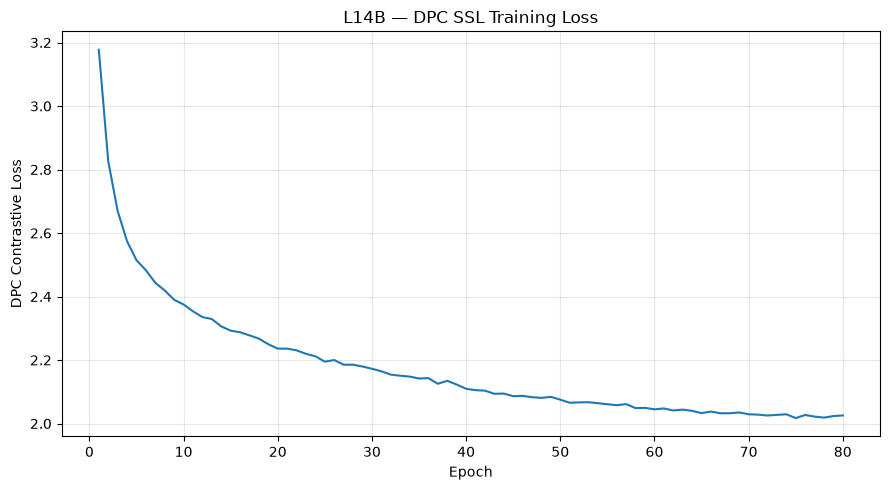

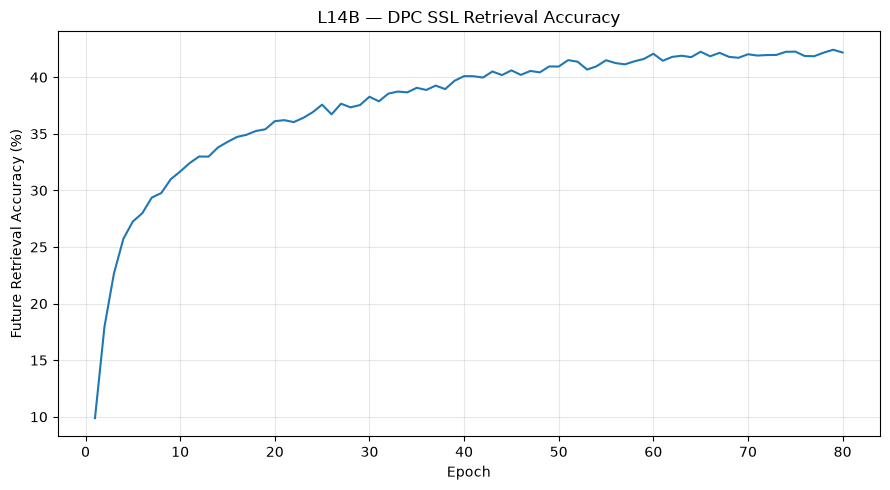


SSL -> SUPERVISED TRANSFER
SSL epoch        : 75
SSL loss         : 2.0171661394229834
Encoder transfer : PASS
GRU transfer     : PASS
Missing keys     : []
Unexpected keys  : []

PHASE 2 — CLASSIFICATION HEAD TRAINING
Trainable parameters: 54,739
HEAD 001/20 | Train Loss 5.92116 | Train T1   0.51% | Val Loss 5.60551 | Val T1   0.47% | Val T5   2.37% | 2.3s
      >>> BEST HEAD CHECKPOINT SAVED
HEAD 002/20 | Train Loss 5.49044 | Train T1   1.71% | Val Loss 5.49235 | Val T1   1.42% | Val T5   3.32% | 1.2s
      >>> BEST HEAD CHECKPOINT SAVED
HEAD 003/20 | Train Loss 5.36155 | Train T1   2.05% | Val Loss 5.44123 | Val T1   0.95% | Val T5   3.32% | 1.2s
HEAD 004/20 | Train Loss 5.22009 | Train T1   1.88% | Val Loss 5.41920 | Val T1   1.90% | Val T5   3.32% | 1.1s
      >>> BEST HEAD CHECKPOINT SAVED
HEAD 005/20 | Train Loss 5.10766 | Train T1   3.93% | Val Loss 5.39417 | Val T1   1.42% | Val T5   4.74% | 1.1s
HEAD 006/20 | Train Loss 5.00009 | Train T1   3.93% | Val Loss 5.39443 | Val T1 

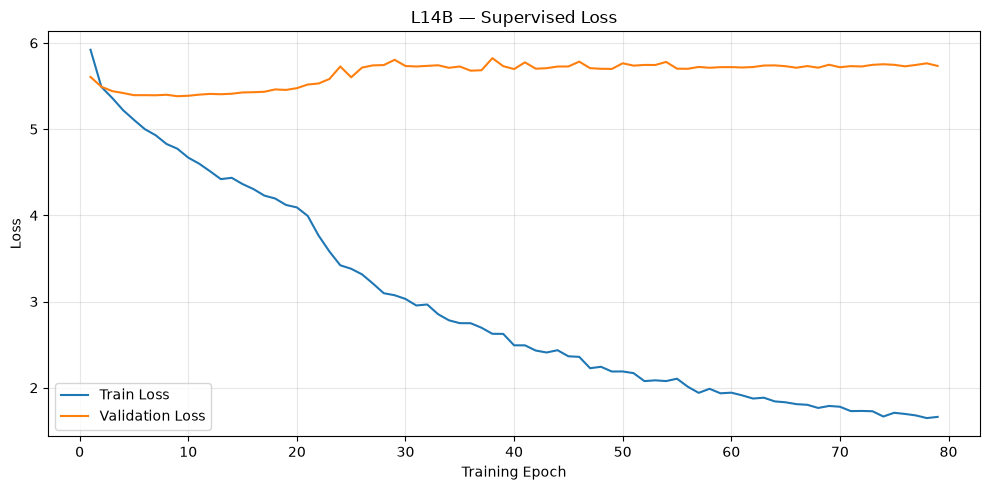

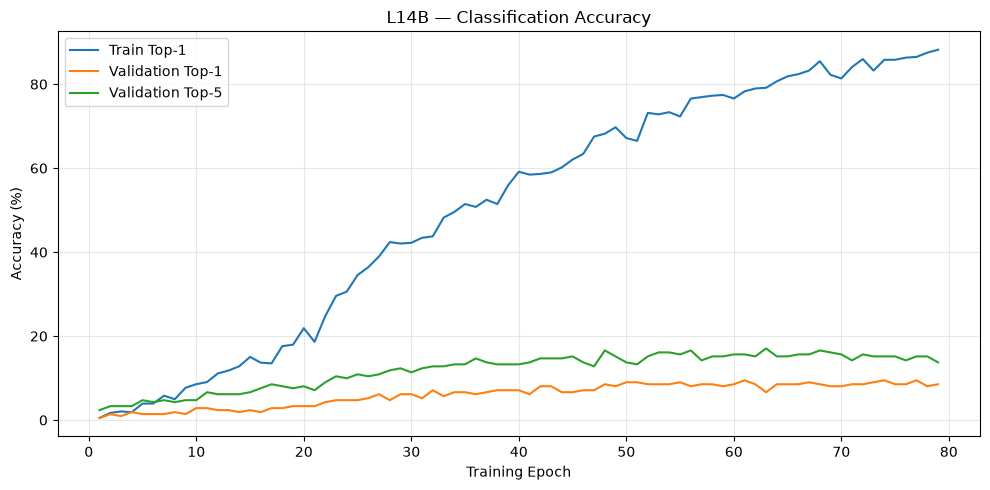


MODEL COMPARISON
stage                           model  val_top1  val_top5
  L10                             GRU  7.110000 13.740000
L10.2           Enhanced Skeleton GRU  3.790000  6.640000
  L11                          BiLSTM  8.530000 17.540000
 L12A                 Two-Hand ST-GCN 18.010000 27.960000
 L12B                      SSL ST-GCN 28.436019 37.914692
 L13B        RGB Temporal Transformer 38.862559 46.445498
 L13C Quality-Aware Multimodal Fusion 36.492891 44.075829
 L14A               VideoMAE Transfer 37.914692 51.658768
 L14B             DPC Sign-Domain SSL  9.478673 15.639810

L14B vs L12B Top-1: -18.96 pp
L14B vs L13B Top-1: -29.38 pp
L14B vs L14A Top-1: -28.44 pp


L14B — FINAL FREEZE
Method               : OpenHands DPC-inspired CISLR two-hand SSL
SSL population       : 6628
Best SSL epoch       : 75
Best SSL loss        : 2.017166

Supervised train     : 585
Validation           : 211
Classes              : 211

Best supervised phase: FINETUNE
Best epoch           : 

In [5]:
# ==================================================================================================
# PARASURG / CISLR — L14B
# OPENHANDS DPC-INSPIRED SIGN-DOMAIN SELF-SUPERVISED PRETRAINING
# COMPLETE SINGLE-CELL IMPLEMENTATION
#
# IMPORTANT SCIENTIFIC CLAIM:
#   This is an OpenHands DPC-inspired adaptation to the existing CISLR two-hand landmark representation.
#   It DOES NOT claim to load the original OpenHands pretrained checkpoint.
#
# PIPELINE:
#   L6 raw landmarks
#       -> leakage-safe SSL population
#       -> 70-frame temporal resampling
#       -> 7 x 10-frame windows
#       -> 42-node two-hand ST-GCN
#       -> DPC SSL
#       -> encoder + GRU transfer
#       -> 211-class head training
#       -> full fine-tuning
#       -> L9 VALIDATION ONLY
#       -> reports/checkpoints/plots/final freeze
#
# L9 TEST:
#   Manifest read ONLY to identify UIDs that must be excluded from SSL.
#   Test videos are NOT loaded, decoded, inferred, or evaluated.
# ==================================================================================================

import os
import gc
import json
import math
import time
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ==================================================================================================
# 0. REPRODUCIBILITY
# ==================================================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


# ==================================================================================================
# 1. DEVICE
# ==================================================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 120)
print("L14B — OPENHANDS DPC-INSPIRED SIGN-DOMAIN SSL")
print("=" * 120)

print("PyTorch :", torch.__version__)
print("Device  :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM    :",
        round(
            torch.cuda.get_device_properties(0).total_memory /
            (1024 ** 3),
            2
        ),
        "GB"
    )

print("=" * 120)


# ==================================================================================================
# 2. PATHS
# ==================================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

LANDMARK_ROOT = (
    PROJECT_ROOT /
    "CISLR_LANDMARK_MODEL"
)

L6_ROOT = (
    LANDMARK_ROOT /
    "audit/l6_full_extraction"
)

RAW_ROOT = (
    L6_ROOT /
    "raw_sequences"
)

L9_ROOT = (
    LANDMARK_ROOT /
    "audit/l9_split_freeze"
)

TRAIN_CSV = (
    L9_ROOT /
    "splits/l9_train_manifest.csv"
)

VAL_CSV = (
    L9_ROOT /
    "splits/l9_validation_manifest.csv"
)

TEST_CSV = (
    L9_ROOT /
    "splits/l9_test_manifest.csv"
)

CLASS_MAPPING_PATH = (
    L9_ROOT /
    "class_mapping/l9_controlled_class_mapping.json"
)


L14B_ROOT = (
    LANDMARK_ROOT /
    "audit/l14_pretrained_sign/l14b_dpc_cislr"
)

MODEL_DIR = L14B_ROOT / "models"
REPORT_DIR = L14B_ROOT / "reports"
PLOT_DIR = L14B_ROOT / "plots"
CACHE_DIR = L14B_ROOT / "cache"

for p in [
    L14B_ROOT,
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR,
    CACHE_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 3. CONFIGURATION
# ==================================================================================================

NUM_CLASSES = 211

NUM_NODES = 42

# X, Y, presence
INPUT_CHANNELS = 3

NUM_WINDOWS = 7
WINDOW_LENGTH = 10

TOTAL_SSL_FRAMES = (
    NUM_WINDOWS *
    WINDOW_LENGTH
)

PRED_STEPS = 3

HIDDEN_CHANNELS = 64
LATENT_DIM = 256

DROPOUT = 0.50


# --------------------------------------------------------------------------------------------------
# SSL
# --------------------------------------------------------------------------------------------------

SSL_BATCH_SIZE = 32
SSL_EPOCHS = 80
SSL_LR = 1e-4
SSL_WEIGHT_DECAY = 1e-5
SSL_TEMPERATURE = 0.10


# --------------------------------------------------------------------------------------------------
# Supervised
# --------------------------------------------------------------------------------------------------

SUP_BATCH_SIZE = 16

HEAD_EPOCHS = 20
HEAD_LR = 1e-3

FINETUNE_EPOCHS = 80
FINETUNE_LR = 2e-4
FINETUNE_WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.10

EARLY_STOP_PATIENCE = 18

NUM_WORKERS = 2


print()
print("CONFIGURATION")
print("-" * 120)

print("Classes             :", NUM_CLASSES)
print("Graph nodes         :", NUM_NODES)
print("Input channels      :", INPUT_CHANNELS)
print("Windows             :", NUM_WINDOWS)
print("Window length       :", WINDOW_LENGTH)
print("Resampled frames    :", TOTAL_SSL_FRAMES)
print("DPC prediction steps:", PRED_STEPS)
print("Latent dimension    :", LATENT_DIM)
print("SSL epochs          :", SSL_EPOCHS)
print("Head epochs         :", HEAD_EPOCHS)
print("Fine-tune epochs    :", FINETUNE_EPOCHS)

print("-" * 120)


# ==================================================================================================
# 4. REQUIRED PATH CHECK
# ==================================================================================================

required_paths = [
    PROJECT_ROOT,
    LANDMARK_ROOT,
    RAW_ROOT,
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV
]

for path in required_paths:

    if not path.exists():
        raise FileNotFoundError(
            f"Required path missing:\n{path}"
        )

print("[PASS] Required project paths exist.")


# ==================================================================================================
# 5. LOAD FROZEN L9 SPLITS
# ==================================================================================================

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)


print()
print("=" * 120)
print("L9 FROZEN SPLIT")
print("=" * 120)

print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))


assert len(train_df) == 585, (
    f"Expected 585 train rows, got {len(train_df)}"
)

assert len(val_df) == 211, (
    f"Expected 211 validation rows, got {len(val_df)}"
)

assert len(test_df) == 211, (
    f"Expected 211 test rows, got {len(test_df)}"
)


for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    if "uid" not in df.columns:

        raise KeyError(
            f"'uid' missing from {name} manifest. "
            f"Columns = {df.columns.tolist()}"
        )


train_uids = set(
    train_df["uid"].astype(str)
)

val_uids = set(
    val_df["uid"].astype(str)
)

test_uids = set(
    test_df["uid"].astype(str)
)


assert len(
    train_uids &
    val_uids
) == 0

assert len(
    train_uids &
    test_uids
) == 0

assert len(
    val_uids &
    test_uids
) == 0


print("Train ∩ Val  :", len(train_uids & val_uids))
print("Train ∩ Test :", len(train_uids & test_uids))
print("Val ∩ Test   :", len(val_uids & test_uids))

print("[PASS] L9 split integrity verified.")
print("[PASS] Test manifest read ONLY for exclusion.")


# ==================================================================================================
# 6. CLASS COLUMN
# ==================================================================================================

def detect_class_column(df):

    candidates = [
        "class_id",
        "label_id",
        "target",
        "class_idx",
        "label"
    ]

    for c in candidates:

        if c in df.columns:
            return c

    return None


CLASS_COL = detect_class_column(
    train_df
)


if CLASS_COL is None:

    if not CLASS_MAPPING_PATH.exists():

        raise RuntimeError(
            "Could not find class column and class mapping is missing."
        )

    with open(
        CLASS_MAPPING_PATH,
        "r"
    ) as f:

        mapping_obj = json.load(
            f
        )

    # Handle common mapping formats.
    if isinstance(mapping_obj, dict):

        if "gloss_to_class" in mapping_obj:

            gloss_to_class = mapping_obj[
                "gloss_to_class"
            ]

        elif "class_to_gloss" in mapping_obj:

            gloss_to_class = {
                str(v): int(k)
                for k, v in mapping_obj[
                    "class_to_gloss"
                ].items()
            }

        else:

            # Try direct gloss -> int mapping
            possible = True

            for k, v in mapping_obj.items():

                try:
                    int(v)

                except Exception:
                    possible = False
                    break

            if possible:

                gloss_to_class = {
                    str(k): int(v)
                    for k, v in mapping_obj.items()
                }

            else:

                raise RuntimeError(
                    "Could not interpret L9 class mapping JSON."
                )

    else:

        raise RuntimeError(
            "Unexpected class mapping JSON structure."
        )


    if "gloss" not in train_df.columns:

        raise RuntimeError(
            "No class column and no gloss column available."
        )


    for df in [
        train_df,
        val_df,
        test_df
    ]:

        df["class_id"] = (
            df["gloss"]
            .astype(str)
            .map(gloss_to_class)
        )


    CLASS_COL = "class_id"


print()
print("Class column:", CLASS_COL)


# Ensure integer class IDs

train_df[CLASS_COL] = (
    train_df[CLASS_COL]
    .astype(int)
)

val_df[CLASS_COL] = (
    val_df[CLASS_COL]
    .astype(int)
)

test_df[CLASS_COL] = (
    test_df[CLASS_COL]
    .astype(int)
)


all_train_classes = sorted(
    train_df[CLASS_COL].unique()
)

assert len(all_train_classes) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes in training, "
    f"found {len(all_train_classes)}"
)

print(
    "[PASS] Controlled vocabulary:",
    len(all_train_classes),
    "classes"
)


# ==================================================================================================
# 7. FIND RAW FILES
# ==================================================================================================

all_raw_files = sorted(
    RAW_ROOT.rglob("*.npz")
)

print()
print("=" * 120)
print("L6 RAW DATA")
print("=" * 120)

print(
    "Raw NPZ files:",
    len(all_raw_files)
)

if len(all_raw_files) < 7000:

    raise RuntimeError(
        f"Expected approximately 7050 raw files, found {len(all_raw_files)}"
    )


raw_by_uid = {
    p.stem: p
    for p in all_raw_files
}


# ==================================================================================================
# 8. ATTACH RAW PATHS TO TRAIN / VALIDATION
# ==================================================================================================

def attach_raw_paths(df):

    df = df.copy()

    paths = []

    missing = []

    for uid in df["uid"].astype(str):

        p = raw_by_uid.get(
            uid
        )

        if p is None:

            missing.append(
                uid
            )

            paths.append(
                None
            )

        else:

            paths.append(
                str(p)
            )

    df["raw_path"] = paths

    if missing:

        raise FileNotFoundError(
            f"Missing {len(missing)} raw files. "
            f"First missing UIDs: {missing[:10]}"
        )

    return df


train_df = attach_raw_paths(
    train_df
)

val_df = attach_raw_paths(
    val_df
)


print(
    "[PASS] All train raw sequences resolved."
)

print(
    "[PASS] All validation raw sequences resolved."
)


# ==================================================================================================
# 9. BUILD LEAKAGE-SAFE SSL POPULATION
# ==================================================================================================

ssl_files = []

excluded_val = 0
excluded_test = 0


for path in all_raw_files:

    uid = path.stem

    if uid in val_uids:

        excluded_val += 1
        continue

    if uid in test_uids:

        excluded_test += 1
        continue

    ssl_files.append(
        path
    )


assert not any(
    p.stem in val_uids
    for p in ssl_files
)

assert not any(
    p.stem in test_uids
    for p in ssl_files
)


print()
print("=" * 120)
print("LEAKAGE-SAFE SSL POPULATION")
print("=" * 120)

print(
    "All raw sequences       :",
    len(all_raw_files)
)

print(
    "Excluded validation UIDs:",
    excluded_val
)

print(
    "Excluded test UIDs      :",
    excluded_test
)

print(
    "Permissible SSL videos  :",
    len(ssl_files)
)

print()
print("[PASS] Validation videos excluded from SSL.")
print("[PASS] Test videos excluded from SSL.")


# ==================================================================================================
# 10. TEMPORAL RESAMPLING
# ==================================================================================================

def temporal_resample(
    arr,
    target_length
):

    T = len(
        arr
    )

    if T == 0:

        raise ValueError(
            "Cannot resample an empty sequence."
        )


    if T == target_length:

        return arr.copy()


    indices = np.linspace(
        0,
        T - 1,
        target_length
    )

    indices = np.round(
        indices
    ).astype(
        np.int64
    )

    indices = np.clip(
        indices,
        0,
        T - 1
    )


    return arr[
        indices
    ]


# ==================================================================================================
# 11. PREPROCESS L6 RAW LANDMARKS
# ==================================================================================================

def preprocess_raw_sequence(
    path,
    target_frames=TOTAL_SSL_FRAMES
):

    z = np.load(
        path,
        allow_pickle=True
    )


    if "world_landmarks" not in z.files:

        raise KeyError(
            f"world_landmarks missing from {path}"
        )

    if "hand_mask" not in z.files:

        raise KeyError(
            f"hand_mask missing from {path}"
        )


    world = np.asarray(
        z["world_landmarks"],
        dtype=np.float32
    )

    mask = np.asarray(
        z["hand_mask"],
        dtype=np.float32
    )


    if (
        world.ndim != 4
        or
        world.shape[1:] != (
            2,
            21,
            3
        )
    ):

        raise ValueError(
            f"Unexpected world_landmarks shape "
            f"{world.shape} in {path.name}"
        )


    if (
        mask.ndim != 2
        or
        mask.shape[1] != 2
    ):

        raise ValueError(
            f"Unexpected hand_mask shape "
            f"{mask.shape} in {path.name}"
        )


    T = world.shape[0]


    # ----------------------------------------------------------------------------------------------
    # XY coordinates only.
    # ----------------------------------------------------------------------------------------------

    xy = world[
        ...,
        :2
    ].copy()


    xy = np.nan_to_num(
        xy,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


    mask = (
        mask > 0
    ).astype(
        np.float32
    )


    # ----------------------------------------------------------------------------------------------
    # Explicitly zero absent hands.
    # ----------------------------------------------------------------------------------------------

    for h in range(2):

        missing = (
            mask[:, h] == 0
        )

        xy[
            missing,
            h,
            :,
            :
        ] = 0.0


    # ----------------------------------------------------------------------------------------------
    # Frame-wise visible-point centering and scaling.
    # ----------------------------------------------------------------------------------------------

    normalized = np.zeros_like(
        xy,
        dtype=np.float32
    )


    for t in range(T):

        visible = []


        for h in range(2):

            if mask[t, h] > 0:

                visible.append(
                    xy[t, h]
                )


        if len(visible) == 0:

            continue


        visible_points = np.concatenate(
            visible,
            axis=0
        )


        center = np.mean(
            visible_points,
            axis=0,
            keepdims=True
        )


        centered = (
            visible_points -
            center
        )


        scale = np.sqrt(
            np.mean(
                np.sum(
                    centered ** 2,
                    axis=1
                )
            )
        )


        scale = max(
            float(scale),
            1e-4
        )


        for h in range(2):

            if mask[t, h] > 0:

                normalized[
                    t,
                    h
                ] = (
                    xy[
                        t,
                        h
                    ] -
                    center
                ) / scale


    # ----------------------------------------------------------------------------------------------
    # 2 hands x 21 joints -> 42 graph nodes
    # ----------------------------------------------------------------------------------------------

    nodes = normalized.reshape(
        T,
        42,
        2
    )


    node_presence = np.repeat(
        mask[
            :,
            :,
            None
        ],
        21,
        axis=2
    ).reshape(
        T,
        42,
        1
    )


    features = np.concatenate(
        [
            nodes,
            node_presence
        ],
        axis=-1
    )


    features = temporal_resample(
        features,
        target_frames
    )


    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    ).astype(
        np.float32
    )


    return features


# ==================================================================================================
# 12. PREPROCESSING SANITY CHECK
# ==================================================================================================

sample_path = ssl_files[0]

sample = preprocess_raw_sequence(
    sample_path
)

print()
print("=" * 120)
print("PREPROCESSING SANITY CHECK")
print("=" * 120)

print(
    "Sample:",
    sample_path.name
)

print(
    "Shape :",
    sample.shape
)

print(
    "Finite:",
    np.isfinite(
        sample
    ).all()
)

print(
    "Min   :",
    float(
        sample.min()
    )
)

print(
    "Max   :",
    float(
        sample.max()
    )
)


assert sample.shape == (
    TOTAL_SSL_FRAMES,
    NUM_NODES,
    INPUT_CHANNELS
)

assert np.isfinite(
    sample
).all()


print(
    "[PASS] Preprocessing operational."
)


# ==================================================================================================
# 13. TWO-HAND GRAPH
# ==================================================================================================

HAND_CONNECTIONS = [

    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),

    (0, 5),
    (5, 6),
    (6, 7),
    (7, 8),

    (0, 9),
    (9, 10),
    (10, 11),
    (11, 12),

    (0, 13),
    (13, 14),
    (14, 15),
    (15, 16),

    (0, 17),
    (17, 18),
    (18, 19),
    (19, 20),

    (5, 9),
    (9, 13),
    (13, 17)
]


def build_two_hand_adjacency():

    A = np.zeros(
        (
            NUM_NODES,
            NUM_NODES
        ),
        dtype=np.float32
    )


    # Self connections

    for i in range(
        NUM_NODES
    ):

        A[
            i,
            i
        ] = 1.0


    # Each hand

    for offset in [
        0,
        21
    ]:

        for a, b in HAND_CONNECTIONS:

            aa = a + offset
            bb = b + offset

            A[
                aa,
                bb
            ] = 1.0

            A[
                bb,
                aa
            ] = 1.0


    # Cross-hand wrist relation

    A[
        0,
        21
    ] = 1.0

    A[
        21,
        0
    ] = 1.0


    degree = A.sum(
        axis=1
    )


    inv_sqrt = 1.0 / np.sqrt(
        np.maximum(
            degree,
            1e-6
        )
    )


    D = np.diag(
        inv_sqrt
    )


    A_norm = (
        D @
        A @
        D
    )


    return torch.tensor(
        A_norm,
        dtype=torch.float32
    )


ADJACENCY = build_two_hand_adjacency()


assert ADJACENCY.shape == (
    42,
    42
)


print()
print(
    "[PASS] Two-hand adjacency:",
    tuple(
        ADJACENCY.shape
    )
)


# ==================================================================================================
# 14. DATA AUGMENTATION
# ==================================================================================================

def augment_landmarks(
    x,
    ssl=True
):

    x = x.copy()


    # Scale

    if ssl:

        scale = np.random.uniform(
            0.90,
            1.10
        )

        rotation_std = 0.08
        noise_std = 0.01

    else:

        scale = np.random.uniform(
            0.92,
            1.08
        )

        rotation_std = 0.06
        noise_std = 0.006


    x[
        ...,
        :2
    ] *= scale


    # Rotation

    angle = np.random.normal(
        0.0,
        rotation_std
    )


    c = np.cos(
        angle
    )

    s = np.sin(
        angle
    )


    R = np.array(
        [
            [c, -s],
            [s, c]
        ],
        dtype=np.float32
    )


    x[
        ...,
        :2
    ] = (
        x[
            ...,
            :2
        ] @
        R.T
    )


    # Noise only on present nodes

    noise = np.random.normal(
        0.0,
        noise_std,
        size=x[
            ...,
            :2
        ].shape
    ).astype(
        np.float32
    )


    presence = x[
        ...,
        2:3
    ]


    x[
        ...,
        :2
    ] += (
        noise *
        presence
    )


    return x


# ==================================================================================================
# 15. DATASETS
# ==================================================================================================

class DPCSSLDataset(
    Dataset
):

    def __init__(
        self,
        paths,
        augment=True
    ):

        self.paths = list(
            paths
        )

        self.augment = augment


    def __len__(
        self
    ):

        return len(
            self.paths
        )


    def __getitem__(
        self,
        index
    ):

        path = self.paths[
            index
        ]


        x = preprocess_raw_sequence(
            path,
            TOTAL_SSL_FRAMES
        )


        if self.augment:

            x = augment_landmarks(
                x,
                ssl=True
            )


        # 70 x 42 x 3
        # -> 7 x 10 x 42 x 3

        x = x.reshape(
            NUM_WINDOWS,
            WINDOW_LENGTH,
            NUM_NODES,
            INPUT_CHANNELS
        )


        # -> 7 x 3 x 10 x 42

        x = np.transpose(
            x,
            (
                0,
                3,
                1,
                2
            )
        )


        return torch.from_numpy(
            np.ascontiguousarray(
                x
            )
        ).float()


class SupervisedCISLRDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        augment=False
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.augment = augment


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        path = Path(
            row[
                "raw_path"
            ]
        )


        x = preprocess_raw_sequence(
            path,
            TOTAL_SSL_FRAMES
        )


        if self.augment:

            x = augment_landmarks(
                x,
                ssl=False
            )


        x = x.reshape(
            NUM_WINDOWS,
            WINDOW_LENGTH,
            NUM_NODES,
            INPUT_CHANNELS
        )


        x = np.transpose(
            x,
            (
                0,
                3,
                1,
                2
            )
        )


        y = int(
            row[
                CLASS_COL
            ]
        )


        return (
            torch.from_numpy(
                np.ascontiguousarray(
                    x
                )
            ).float(),

            torch.tensor(
                y,
                dtype=torch.long
            )
        )


# ==================================================================================================
# 16. DATALOADERS
# ==================================================================================================

ssl_dataset = DPCSSLDataset(
    ssl_files,
    augment=True
)

train_dataset = SupervisedCISLRDataset(
    train_df,
    augment=True
)

val_dataset = SupervisedCISLRDataset(
    val_df,
    augment=False
)


ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=SSL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
    persistent_workers=(
        NUM_WORKERS > 0
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=SUP_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=(
        NUM_WORKERS > 0
    )
)


val_loader = DataLoader(
    val_dataset,
    batch_size=SUP_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    persistent_workers=(
        NUM_WORKERS > 0
    )
)


print()
print("=" * 120)
print("DATALOADERS")
print("=" * 120)

print(
    "SSL samples  :",
    len(
        ssl_dataset
    )
)

print(
    "Train samples:",
    len(
        train_dataset
    )
)

print(
    "Val samples  :",
    len(
        val_dataset
    )
)


test_batch = next(
    iter(
        ssl_loader
    )
)


print(
    "SSL batch shape:",
    tuple(
        test_batch.shape
    )
)


assert test_batch.shape[
    1:
] == (
    NUM_WINDOWS,
    INPUT_CHANNELS,
    WINDOW_LENGTH,
    NUM_NODES
)


del test_batch

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "[PASS] DataLoaders operational."
)


# ==================================================================================================
# 17. GRAPH CONVOLUTION
# ==================================================================================================

class GraphConv(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )


    def forward(
        self,
        x,
        A
    ):

        x = torch.einsum(
            "nctv,vw->nctw",
            x,
            A
        )


        return self.conv(
            x
        )


# ==================================================================================================
# 18. ST-GCN BLOCK
# ==================================================================================================

class STGCNBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        dropout=0.0
    ):

        super().__init__()


        self.gcn = GraphConv(
            in_channels,
            out_channels
        )


        self.bn1 = nn.BatchNorm2d(
            out_channels
        )


        self.temporal = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=(
                3,
                1
            ),
            padding=(
                1,
                0
            ),
            bias=False
        )


        self.bn2 = nn.BatchNorm2d(
            out_channels
        )


        self.dropout = nn.Dropout(
            dropout
        )


        if in_channels == out_channels:

            self.residual = nn.Identity()

        else:

            self.residual = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )


    def forward(
        self,
        x,
        A
    ):

        residual = self.residual(
            x
        )


        x = self.gcn(
            x,
            A
        )


        x = self.bn1(
            x
        )


        x = F.relu(
            x,
            inplace=True
        )


        x = self.temporal(
            x
        )


        x = self.bn2(
            x
        )


        x = self.dropout(
            x
        )


        x = x + residual


        return F.relu(
            x,
            inplace=True
        )


# ==================================================================================================
# 19. ST-GCN ENCODER
# ==================================================================================================

class STGCNEncoder(
    nn.Module
):

    def __init__(
        self,
        adjacency,
        input_channels=3,
        hidden_channels=64,
        latent_dim=256,
        dropout=0.30
    ):

        super().__init__()


        self.register_buffer(
            "A",
            adjacency.clone()
        )


        self.block1 = STGCNBlock(
            input_channels,
            hidden_channels,
            dropout
        )


        self.block2 = STGCNBlock(
            hidden_channels,
            hidden_channels,
            dropout
        )


        self.block3 = STGCNBlock(
            hidden_channels,
            128,
            dropout
        )


        self.block4 = STGCNBlock(
            128,
            128,
            dropout
        )


        self.projection = nn.Sequential(

            nn.Linear(
                128,
                latent_dim
            ),

            nn.LayerNorm(
                latent_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.block1(
            x,
            self.A
        )

        x = self.block2(
            x,
            self.A
        )

        x = self.block3(
            x,
            self.A
        )

        x = self.block4(
            x,
            self.A
        )


        # Global spatiotemporal pooling

        x = x.mean(
            dim=(
                -1,
                -2
            )
        )


        x = self.projection(
            x
        )


        return x


# ==================================================================================================
# 20. DPC MODEL
# ==================================================================================================

class DPCModel(
    nn.Module
):

    def __init__(
        self,
        encoder,
        latent_dim=256,
        pred_steps=3
    ):

        super().__init__()


        self.encoder = encoder

        self.latent_dim = latent_dim

        self.pred_steps = pred_steps


        self.agg = nn.GRU(
            latent_dim,
            latent_dim,
            batch_first=True
        )


        self.predictor = nn.Sequential(

            nn.Linear(
                latent_dim,
                latent_dim
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                latent_dim,
                latent_dim
            )
        )


        self._init_weights(
            self.agg
        )

        self._init_weights(
            self.predictor
        )


    def _init_weights(
        self,
        module
    ):

        for name, param in module.named_parameters():

            if "bias" in name:

                nn.init.constant_(
                    param,
                    0.0
                )

            elif (
                "weight" in name
                and
                param.ndim >= 2
            ):

                nn.init.orthogonal_(
                    param,
                    gain=1.0
                )


    def encode_windows(
        self,
        block
    ):

        B, N, C, T, V = block.shape


        flat = block.reshape(
            B * N,
            C,
            T,
            V
        )


        features = self.encoder(
            flat
        )


        features = features.reshape(
            B,
            N,
            self.latent_dim
        )


        return features


    def forward(
        self,
        block
    ):

        features = self.encode_windows(
            block
        )


        B, N, D = features.shape


        if N <= self.pred_steps:

            raise ValueError(
                "Number of windows must be greater than pred_steps."
            )


        future_features = features[
            :,
            N - self.pred_steps:
        ]


        observed = F.relu(
            features[
                :,
                :N - self.pred_steps
            ]
        )


        _, hidden = self.agg(
            observed
        )


        hidden = hidden[
            -1
        ]


        predictions = []


        for _ in range(
            self.pred_steps
        ):

            pred = self.predictor(
                hidden
            )


            predictions.append(
                pred
            )


            _, next_hidden = self.agg(
                F.relu(
                    pred
                ).unsqueeze(
                    1
                ),
                hidden.unsqueeze(
                    0
                )
            )


            hidden = next_hidden[
                -1
            ]


        predictions = torch.stack(
            predictions,
            dim=1
        )


        return (
            predictions,
            future_features
        )


# ==================================================================================================
# 21. DPC CONTRASTIVE LOSS
# ==================================================================================================

def dpc_contrastive_loss(
    predictions,
    targets,
    temperature=0.10
):

    B, P, D = predictions.shape


    losses = []

    accuracies = []


    for p in range(
        P
    ):

        pred = F.normalize(
            predictions[
                :,
                p
            ],
            dim=-1
        )


        target = F.normalize(
            targets[
                :,
                p
            ],
            dim=-1
        )


        logits = (
            pred @
            target.T
        ) / temperature


        labels = torch.arange(
            B,
            device=logits.device
        )


        loss = F.cross_entropy(
            logits,
            labels
        )


        accuracy = (
            logits.argmax(
                dim=1
            ) ==
            labels
        ).float().mean()


        losses.append(
            loss
        )

        accuracies.append(
            accuracy
        )


    return (
        torch.stack(
            losses
        ).mean(),

        torch.stack(
            accuracies
        ).mean()
    )


# ==================================================================================================
# 22. BUILD DPC MODEL
# ==================================================================================================

encoder = STGCNEncoder(

    adjacency=ADJACENCY,

    input_channels=INPUT_CHANNELS,

    hidden_channels=HIDDEN_CHANNELS,

    latent_dim=LATENT_DIM,

    dropout=0.30
)


dpc_model = DPCModel(

    encoder=encoder,

    latent_dim=LATENT_DIM,

    pred_steps=PRED_STEPS

).to(
    DEVICE
)


# Model sanity test

dummy = torch.randn(
    2,
    NUM_WINDOWS,
    INPUT_CHANNELS,
    WINDOW_LENGTH,
    NUM_NODES,
    device=DEVICE
)


with torch.no_grad():

    dummy_pred, dummy_future = dpc_model(
        dummy
    )


assert dummy_pred.shape == (
    2,
    PRED_STEPS,
    LATENT_DIM
)

assert dummy_future.shape == (
    2,
    PRED_STEPS,
    LATENT_DIM
)


print()
print("=" * 120)
print("MODEL SANITY CHECK")
print("=" * 120)

print(
    "Prediction shape:",
    tuple(
        dummy_pred.shape
    )
)

print(
    "Future shape    :",
    tuple(
        dummy_future.shape
    )
)


total_dpc_params = sum(
    p.numel()
    for p in dpc_model.parameters()
)


print(
    f"DPC parameters  : {total_dpc_params:,}"
)

print(
    "[PASS] DPC architecture operational."
)


del dummy
del dummy_pred
del dummy_future

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ==================================================================================================
# 23. SSL CHECKPOINT PATHS
# ==================================================================================================

SSL_BEST_PATH = (
    MODEL_DIR /
    "l14b_best_dpc_ssl.pt"
)

SSL_LAST_PATH = (
    MODEL_DIR /
    "l14b_last_dpc_ssl.pt"
)


# ==================================================================================================
# 24. SSL TRAINING
# ==================================================================================================

ssl_optimizer = torch.optim.AdamW(

    dpc_model.parameters(),

    lr=SSL_LR,

    weight_decay=SSL_WEIGHT_DECAY
)


ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    ssl_optimizer,

    T_max=SSL_EPOCHS
)


ssl_history = []

best_ssl_loss = float(
    "inf"
)

best_ssl_epoch = -1


print()
print("=" * 120)
print("PHASE 1 — DPC SELF-SUPERVISED PRETRAINING")
print("=" * 120)

print(
    "SSL videos:",
    len(
        ssl_dataset
    )
)

print(
    "Epochs    :",
    SSL_EPOCHS
)

print(
    "Batch size:",
    SSL_BATCH_SIZE
)

print(
    "Device    :",
    DEVICE
)

print("=" * 120)


for epoch in range(
    1,
    SSL_EPOCHS + 1
):

    epoch_start = time.time()


    dpc_model.train()


    running_loss = 0.0

    running_acc = 0.0

    seen = 0


    for batch in ssl_loader:

        batch = batch.to(
            DEVICE,
            non_blocking=True
        )


        ssl_optimizer.zero_grad(
            set_to_none=True
        )


        predictions, targets = dpc_model(
            batch
        )


        loss, retrieval_acc = dpc_contrastive_loss(

            predictions,

            targets,

            temperature=SSL_TEMPERATURE
        )


        if not torch.isfinite(
            loss
        ):

            raise RuntimeError(
                "Non-finite SSL loss detected."
            )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            dpc_model.parameters(),
            max_norm=5.0
        )


        ssl_optimizer.step()


        B = batch.size(
            0
        )


        running_loss += (
            loss.item() *
            B
        )


        running_acc += (
            retrieval_acc.item() *
            B
        )


        seen += B


    ssl_scheduler.step()


    epoch_loss = (
        running_loss /
        max(
            seen,
            1
        )
    )


    epoch_acc = (
        running_acc /
        max(
            seen,
            1
        )
    )


    elapsed = (
        time.time() -
        epoch_start
    )


    current_lr = (
        ssl_optimizer
        .param_groups[0]["lr"]
    )


    ssl_history.append(
        {
            "epoch":
                epoch,

            "ssl_loss":
                epoch_loss,

            "ssl_retrieval_acc":
                epoch_acc,

            "lr":
                current_lr,

            "seconds":
                elapsed
        }
    )


    print(
        f"SSL {epoch:03d}/{SSL_EPOCHS} | "
        f"Loss {epoch_loss:.6f} | "
        f"Retrieval {epoch_acc*100:6.2f}% | "
        f"LR {current_lr:.2e} | "
        f"{elapsed:.1f}s"
    )


    ssl_checkpoint = {

        "stage":
            "L14B",

        "phase":
            "DPC_SSL",

        "epoch":
            epoch,

        "model_state_dict":
            dpc_model.state_dict(),

        "encoder_state_dict":
            dpc_model.encoder.state_dict(),

        "optimizer_state_dict":
            ssl_optimizer.state_dict(),

        "ssl_loss":
            epoch_loss,

        "ssl_retrieval_acc":
            epoch_acc,

        "num_windows":
            NUM_WINDOWS,

        "window_length":
            WINDOW_LENGTH,

        "pred_steps":
            PRED_STEPS,

        "latent_dim":
            LATENT_DIM,

        "num_nodes":
            NUM_NODES,

        "input_channels":
            INPUT_CHANNELS,

        "ssl_population":
            len(
                ssl_dataset
            ),

        "validation_excluded_from_ssl":
            True,

        "test_excluded_from_ssl":
            True,

        "seed":
            SEED,

        "method":
            "OpenHands DPC-inspired CISLR two-hand SSL"
    }


    torch.save(
        ssl_checkpoint,
        SSL_LAST_PATH
    )


    if epoch_loss < best_ssl_loss:

        best_ssl_loss = epoch_loss

        best_ssl_epoch = epoch


        torch.save(
            ssl_checkpoint,
            SSL_BEST_PATH
        )


        print(
            "      >>> BEST SSL CHECKPOINT SAVED"
        )


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ==================================================================================================
# 25. SAVE SSL HISTORY
# ==================================================================================================

ssl_history_df = pd.DataFrame(
    ssl_history
)


ssl_history_path = (
    REPORT_DIR /
    "l14b_ssl_history.csv"
)


ssl_history_df.to_csv(
    ssl_history_path,
    index=False
)


print()
print("=" * 120)
print("SSL PRETRAINING COMPLETE")
print("=" * 120)

print(
    "Best SSL epoch:",
    best_ssl_epoch
)

print(
    "Best SSL loss :",
    best_ssl_loss
)

print(
    "Checkpoint    :",
    SSL_BEST_PATH
)


# ==================================================================================================
# 26. SSL PLOTS
# ==================================================================================================

plt.figure(
    figsize=(
        9,
        5
    )
)


plt.plot(
    ssl_history_df[
        "epoch"
    ],
    ssl_history_df[
        "ssl_loss"
    ]
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "DPC Contrastive Loss"
)

plt.title(
    "L14B — DPC SSL Training Loss"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "l14b_ssl_loss.png",
    dpi=160
)

plt.show()


plt.figure(
    figsize=(
        9,
        5
    )
)


plt.plot(
    ssl_history_df[
        "epoch"
    ],
    ssl_history_df[
        "ssl_retrieval_acc"
    ] * 100
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Future Retrieval Accuracy (%)"
)

plt.title(
    "L14B — DPC SSL Retrieval Accuracy"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    PLOT_DIR /
    "l14b_ssl_retrieval_accuracy.png",
    dpi=160
)

plt.show()


# ==================================================================================================
# 27. SUPERVISED DPC CLASSIFIER
# ==================================================================================================

class DPCClassifier(
    nn.Module
):

    def __init__(
        self,
        encoder,
        num_classes,
        latent_dim=256,
        dropout=0.50
    ):

        super().__init__()


        self.encoder = encoder

        self.latent_dim = latent_dim


        self.agg = nn.GRU(
            latent_dim,
            latent_dim,
            batch_first=True
        )


        self.final_norm = nn.LayerNorm(
            latent_dim
        )


        self.classifier = nn.Sequential(

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                latent_dim,
                num_classes
            )
        )


    def forward(
        self,
        block
    ):

        B, N, C, T, V = block.shape


        flat = block.reshape(
            B * N,
            C,
            T,
            V
        )


        features = self.encoder(
            flat
        )


        features = features.reshape(
            B,
            N,
            self.latent_dim
        )


        _, hidden = self.agg(
            F.relu(
                features
            )
        )


        representation = hidden[
            -1
        ]


        representation = self.final_norm(
            representation
        )


        logits = self.classifier(
            representation
        )


        return logits


# ==================================================================================================
# 28. LOAD BEST SSL CHECKPOINT
# ==================================================================================================

ssl_ckpt = torch.load(
    SSL_BEST_PATH,
    map_location="cpu",
    weights_only=False
)


pretrained_encoder = STGCNEncoder(

    adjacency=ADJACENCY,

    input_channels=INPUT_CHANNELS,

    hidden_channels=HIDDEN_CHANNELS,

    latent_dim=LATENT_DIM,

    dropout=0.30
)


pretrained_encoder.load_state_dict(
    ssl_ckpt[
        "encoder_state_dict"
    ],
    strict=True
)


classifier_model = DPCClassifier(

    encoder=pretrained_encoder,

    num_classes=NUM_CLASSES,

    latent_dim=LATENT_DIM,

    dropout=DROPOUT
)


# ==================================================================================================
# 29. TRANSFER SSL GRU
# ==================================================================================================

ssl_full_state = ssl_ckpt[
    "model_state_dict"
]


gru_state = {

    key.replace(
        "agg.",
        "",
        1
    ):
        value

    for key, value
    in ssl_full_state.items()

    if key.startswith(
        "agg."
    )
}


gru_load_result = (
    classifier_model
    .agg
    .load_state_dict(
        gru_state,
        strict=True
    )
)


classifier_model = classifier_model.to(
    DEVICE
)


print()
print("=" * 120)
print("SSL -> SUPERVISED TRANSFER")
print("=" * 120)

print(
    "SSL epoch        :",
    ssl_ckpt[
        "epoch"
    ]
)

print(
    "SSL loss         :",
    ssl_ckpt[
        "ssl_loss"
    ]
)

print(
    "Encoder transfer : PASS"
)

print(
    "GRU transfer     : PASS"
)

print(
    "Missing keys     :",
    gru_load_result.missing_keys
)

print(
    "Unexpected keys  :",
    gru_load_result.unexpected_keys
)


# ==================================================================================================
# 30. METRICS
# ==================================================================================================

@torch.no_grad()
def evaluate_classifier(
    model,
    loader
):

    model.eval()


    total_loss = 0.0

    total = 0

    top1_correct = 0

    top5_correct = 0


    all_targets = []

    all_predictions = []

    all_top5 = []


    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )


        y = y.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            x
        )


        loss = F.cross_entropy(
            logits,
            y
        )


        B = y.size(
            0
        )


        total_loss += (
            loss.item() *
            B
        )


        total += B


        top1 = logits.argmax(
            dim=1
        )


        top1_correct += (
            top1 ==
            y
        ).sum().item()


        k = min(
            5,
            logits.size(
                1
            )
        )


        top5 = logits.topk(
            k,
            dim=1
        ).indices


        top5_correct += (
            top5 ==
            y.unsqueeze(
                1
            )
        ).any(
            dim=1
        ).sum().item()


        all_targets.extend(
            y.detach()
            .cpu()
            .tolist()
        )


        all_predictions.extend(
            top1.detach()
            .cpu()
            .tolist()
        )


        all_top5.extend(
            top5.detach()
            .cpu()
            .tolist()
        )


    return {

        "loss":
            total_loss /
            max(
                total,
                1
            ),

        "top1":
            100.0 *
            top1_correct /
            max(
                total,
                1
            ),

        "top5":
            100.0 *
            top5_correct /
            max(
                total,
                1
            ),

        "targets":
            all_targets,

        "predictions":
            all_predictions,

        "top5_predictions":
            all_top5
    }


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()


    running_loss = 0.0

    total = 0

    correct = 0


    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )


        y = y.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            x
        )


        loss = criterion(
            logits,
            y
        )


        if not torch.isfinite(
            loss
        ):

            raise RuntimeError(
                "Non-finite supervised loss detected."
            )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )


        optimizer.step()


        B = y.size(
            0
        )


        running_loss += (
            loss.item() *
            B
        )


        total += B


        correct += (
            logits.argmax(
                dim=1
            ) ==
            y
        ).sum().item()


    return (

        running_loss /
        max(
            total,
            1
        ),

        100.0 *
        correct /
        max(
            total,
            1
        )
    )


# ==================================================================================================
# 31. STAGE 1 — HEAD TRAINING
# ==================================================================================================

for p in classifier_model.encoder.parameters():

    p.requires_grad = False


for p in classifier_model.agg.parameters():

    p.requires_grad = False


for p in classifier_model.final_norm.parameters():

    p.requires_grad = True


for p in classifier_model.classifier.parameters():

    p.requires_grad = True


criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


head_optimizer = torch.optim.AdamW(

    filter(
        lambda p:
            p.requires_grad,
        classifier_model.parameters()
    ),

    lr=HEAD_LR,

    weight_decay=1e-4
)


HEAD_BEST_PATH = (
    MODEL_DIR /
    "l14b_stage1_best_head.pt"
)


head_history = []

best_head_top1 = -1.0


print()
print("=" * 120)
print("PHASE 2 — CLASSIFICATION HEAD TRAINING")
print("=" * 120)


print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in classifier_model.parameters() if p.requires_grad):,}"
)


for epoch in range(
    1,
    HEAD_EPOCHS + 1
):

    start = time.time()


    train_loss, train_top1 = train_one_epoch(

        classifier_model,

        train_loader,

        head_optimizer,

        criterion
    )


    val_metrics = evaluate_classifier(

        classifier_model,

        val_loader
    )


    head_history.append(
        {
            "phase":
                "HEAD",

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "train_top1":
                train_top1,

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_top1":
                val_metrics[
                    "top1"
                ],

            "val_top5":
                val_metrics[
                    "top5"
                ]
        }
    )


    print(
        f"HEAD {epoch:03d}/{HEAD_EPOCHS} | "
        f"Train Loss {train_loss:.5f} | "
        f"Train T1 {train_top1:6.2f}% | "
        f"Val Loss {val_metrics['loss']:.5f} | "
        f"Val T1 {val_metrics['top1']:6.2f}% | "
        f"Val T5 {val_metrics['top5']:6.2f}% | "
        f"{time.time()-start:.1f}s"
    )


    if (
        val_metrics[
            "top1"
        ] >
        best_head_top1
    ):

        best_head_top1 = (
            val_metrics[
                "top1"
            ]
        )


        torch.save(
            {

                "stage":
                    "L14B",

                "phase":
                    "HEAD",

                "epoch":
                    epoch,

                "model_state_dict":
                    classifier_model.state_dict(),

                "val_top1":
                    val_metrics[
                        "top1"
                    ],

                "val_top5":
                    val_metrics[
                        "top5"
                    ],

                "val_loss":
                    val_metrics[
                        "loss"
                    ],

                "ssl_checkpoint":
                    str(
                        SSL_BEST_PATH
                    ),

                "test_used":
                    False

            },
            HEAD_BEST_PATH
        )


        print(
            "      >>> BEST HEAD CHECKPOINT SAVED"
        )


# ==================================================================================================
# 32. LOAD BEST HEAD
# ==================================================================================================

head_ckpt = torch.load(
    HEAD_BEST_PATH,
    map_location=DEVICE,
    weights_only=False
)


classifier_model.load_state_dict(
    head_ckpt[
        "model_state_dict"
    ],
    strict=True
)


# ==================================================================================================
# 33. STAGE 2 — FULL FINE-TUNING
# ==================================================================================================

for p in classifier_model.parameters():

    p.requires_grad = True


finetune_optimizer = torch.optim.AdamW(

    [

        {
            "params":
                classifier_model.encoder.parameters(),

            "lr":
                FINETUNE_LR *
                0.35
        },

        {
            "params":
                classifier_model.agg.parameters(),

            "lr":
                FINETUNE_LR *
                0.50
        },

        {
            "params":
                list(
                    classifier_model
                    .final_norm
                    .parameters()
                )
                +
                list(
                    classifier_model
                    .classifier
                    .parameters()
                ),

            "lr":
                FINETUNE_LR
        }

    ],

    weight_decay=
        FINETUNE_WEIGHT_DECAY
)


finetune_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(

        finetune_optimizer,

        T_max=
            FINETUNE_EPOCHS
    )
)


BEST_MODEL_PATH = (
    MODEL_DIR /
    "l14b_best_dpc_classifier.pt"
)


LAST_MODEL_PATH = (
    MODEL_DIR /
    "l14b_last_dpc_classifier.pt"
)


best_val_top1 = float(
    head_ckpt[
        "val_top1"
    ]
)


best_val_top5 = float(
    head_ckpt[
        "val_top5"
    ]
)


best_val_loss = float(
    head_ckpt[
        "val_loss"
    ]
)


best_phase = "HEAD"

best_epoch = int(
    head_ckpt[
        "epoch"
    ]
)


patience_counter = 0


finetune_history = []


# Save head as provisional global best before fine-tuning.
torch.save(
    {

        "stage":
            "L14B",

        "phase":
            "HEAD",

        "epoch":
            best_epoch,

        "model_state_dict":
            head_ckpt[
                "model_state_dict"
            ],

        "val_top1":
            best_val_top1,

        "val_top5":
            best_val_top5,

        "val_loss":
            best_val_loss,

        "ssl_checkpoint":
            str(
                SSL_BEST_PATH
            ),

        "num_classes":
            NUM_CLASSES,

        "num_windows":
            NUM_WINDOWS,

        "window_length":
            WINDOW_LENGTH,

        "num_nodes":
            NUM_NODES,

        "input_channels":
            INPUT_CHANNELS,

        "latent_dim":
            LATENT_DIM,

        "pred_steps":
            PRED_STEPS,

        "seed":
            SEED,

        "test_used":
            False,

        "method":
            "OpenHands DPC-inspired CISLR two-hand sign-domain SSL"

    },
    BEST_MODEL_PATH
)


print()
print("=" * 120)
print("PHASE 3 — FULL SUPERVISED FINE-TUNING")
print("=" * 120)

print(
    f"Initial best validation Top-1: {best_val_top1:.6f}%"
)


for epoch in range(
    1,
    FINETUNE_EPOCHS + 1
):

    start = time.time()


    train_loss, train_top1 = train_one_epoch(

        classifier_model,

        train_loader,

        finetune_optimizer,

        criterion
    )


    val_metrics = evaluate_classifier(

        classifier_model,

        val_loader
    )


    finetune_scheduler.step()


    finetune_history.append(
        {

            "phase":
                "FINETUNE",

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "train_top1":
                train_top1,

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_top1":
                val_metrics[
                    "top1"
                ],

            "val_top5":
                val_metrics[
                    "top5"
                ],

            "encoder_lr":
                finetune_optimizer
                .param_groups[0]["lr"],

            "gru_lr":
                finetune_optimizer
                .param_groups[1]["lr"],

            "head_lr":
                finetune_optimizer
                .param_groups[2]["lr"]
        }
    )


    print(
        f"FT {epoch:03d}/{FINETUNE_EPOCHS} | "
        f"Train Loss {train_loss:.5f} | "
        f"Train T1 {train_top1:6.2f}% | "
        f"Val Loss {val_metrics['loss']:.5f} | "
        f"Val T1 {val_metrics['top1']:6.2f}% | "
        f"Val T5 {val_metrics['top5']:6.2f}% | "
        f"{time.time()-start:.1f}s"
    )


    # ----------------------------------------------------------------------------------------------
    # Primary model-selection metric = validation Top-1.
    # Tie-break = Top-5, then lower validation loss.
    # ----------------------------------------------------------------------------------------------

    improved = False


    if (
        val_metrics[
            "top1"
        ] >
        best_val_top1
    ):

        improved = True


    elif math.isclose(
        val_metrics[
            "top1"
        ],
        best_val_top1,
        rel_tol=0.0,
        abs_tol=1e-12
    ):

        if (
            val_metrics[
                "top5"
            ] >
            best_val_top5
        ):

            improved = True


        elif math.isclose(
            val_metrics[
                "top5"
            ],
            best_val_top5,
            rel_tol=0.0,
            abs_tol=1e-12
        ):

            if (
                val_metrics[
                    "loss"
                ] <
                best_val_loss
            ):

                improved = True


    if improved:

        best_val_top1 = float(
            val_metrics[
                "top1"
            ]
        )


        best_val_top5 = float(
            val_metrics[
                "top5"
            ]
        )


        best_val_loss = float(
            val_metrics[
                "loss"
            ]
        )


        best_epoch = epoch

        best_phase = "FINETUNE"

        patience_counter = 0


        torch.save(
            {

                "stage":
                    "L14B",

                "phase":
                    "FINETUNE",

                "epoch":
                    epoch,

                "model_state_dict":
                    classifier_model.state_dict(),

                "val_top1":
                    best_val_top1,

                "val_top5":
                    best_val_top5,

                "val_loss":
                    best_val_loss,

                "ssl_checkpoint":
                    str(
                        SSL_BEST_PATH
                    ),

                "num_classes":
                    NUM_CLASSES,

                "num_windows":
                    NUM_WINDOWS,

                "window_length":
                    WINDOW_LENGTH,

                "num_nodes":
                    NUM_NODES,

                "input_channels":
                    INPUT_CHANNELS,

                "latent_dim":
                    LATENT_DIM,

                "pred_steps":
                    PRED_STEPS,

                "seed":
                    SEED,

                "test_used":
                    False,

                "method":
                    "OpenHands DPC-inspired CISLR two-hand sign-domain SSL"

            },
            BEST_MODEL_PATH
        )


        print(
            "      >>> NEW BEST L14B CHECKPOINT SAVED"
        )


    else:

        patience_counter += 1


    torch.save(
        {

            "stage":
                "L14B",

            "phase":
                "FINETUNE",

            "epoch":
                epoch,

            "model_state_dict":
                classifier_model.state_dict(),

            "val_top1":
                val_metrics[
                    "top1"
                ],

            "val_top5":
                val_metrics[
                    "top5"
                ],

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "test_used":
                False

        },
        LAST_MODEL_PATH
    )


    if (
        patience_counter >=
        EARLY_STOP_PATIENCE
    ):

        print()
        print(
            f"[EARLY STOP] No validation improvement for "
            f"{EARLY_STOP_PATIENCE} epochs."
        )

        break


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ==================================================================================================
# 34. SAVE SUPERVISED HISTORY
# ==================================================================================================

head_history_df = pd.DataFrame(
    head_history
)


finetune_history_df = pd.DataFrame(
    finetune_history
)


supervised_history_df = pd.concat(
    [
        head_history_df,
        finetune_history_df
    ],
    ignore_index=True
)


supervised_history_path = (
    REPORT_DIR /
    "l14b_supervised_training_history.csv"
)


supervised_history_df.to_csv(
    supervised_history_path,
    index=False
)


# ==================================================================================================
# 35. LOAD FINAL BEST MODEL
# ==================================================================================================

best_ckpt = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)


classifier_model.load_state_dict(
    best_ckpt[
        "model_state_dict"
    ],
    strict=True
)


# ==================================================================================================
# 36. FINAL VALIDATION
# ==================================================================================================

final_val = evaluate_classifier(

    classifier_model,

    val_loader
)


print()
print("=" * 120)
print("L14B FINAL VALIDATION")
print("=" * 120)

print(
    "Best phase :",
    best_ckpt[
        "phase"
    ]
)

print(
    "Best epoch :",
    best_ckpt[
        "epoch"
    ]
)

print(
    f"Top-1      : {final_val['top1']:.6f}%"
)

print(
    f"Top-5      : {final_val['top5']:.6f}%"
)

print(
    f"Loss       : {final_val['loss']:.6f}"
)


targets_np = np.asarray(
    final_val[
        "targets"
    ]
)


predictions_np = np.asarray(
    final_val[
        "predictions"
    ]
)


correct_top1 = int(
    (
        targets_np ==
        predictions_np
    ).sum()
)


print(
    f"Correct     : {correct_top1}/{len(targets_np)}"
)

print()
print(
    "TEST SET USED: NO"
)

print("=" * 120)


# ==================================================================================================
# 37. SAVE VALIDATION PREDICTIONS
# ==================================================================================================

val_predictions_df = val_df.copy()


val_predictions_df[
    "l14b_target_class"
] = final_val[
    "targets"
]


val_predictions_df[
    "l14b_predicted_class"
] = final_val[
    "predictions"
]


val_predictions_df[
    "l14b_correct"
] = (

    val_predictions_df[
        "l14b_target_class"
    ]

    ==

    val_predictions_df[
        "l14b_predicted_class"
    ]
)


val_predictions_df[
    "l14b_top5_classes"
] = [

    json.dumps(
        values
    )

    for values
    in final_val[
        "top5_predictions"
    ]
]


validation_predictions_path = (
    REPORT_DIR /
    "l14b_validation_predictions.csv"
)


val_predictions_df.to_csv(
    validation_predictions_path,
    index=False
)


# ==================================================================================================
# 38. SUPERVISED TRAINING PLOTS
# ==================================================================================================

if len(
    supervised_history_df
) > 0:

    x_axis = np.arange(
        1,
        len(
            supervised_history_df
        ) + 1
    )


    plt.figure(
        figsize=(
            10,
            5
        )
    )


    plt.plot(
        x_axis,
        supervised_history_df[
            "train_loss"
        ],
        label="Train Loss"
    )


    plt.plot(
        x_axis,
        supervised_history_df[
            "val_loss"
        ],
        label="Validation Loss"
    )


    plt.xlabel(
        "Training Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "L14B — Supervised Loss"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    plt.savefig(
        PLOT_DIR /
        "l14b_loss_curve.png",
        dpi=160
    )

    plt.show()


    plt.figure(
        figsize=(
            10,
            5
        )
    )


    plt.plot(
        x_axis,
        supervised_history_df[
            "train_top1"
        ],
        label="Train Top-1"
    )


    plt.plot(
        x_axis,
        supervised_history_df[
            "val_top1"
        ],
        label="Validation Top-1"
    )


    plt.plot(
        x_axis,
        supervised_history_df[
            "val_top5"
        ],
        label="Validation Top-5"
    )


    plt.xlabel(
        "Training Epoch"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.title(
        "L14B — Classification Accuracy"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    plt.savefig(
        PLOT_DIR /
        "l14b_accuracy_curve.png",
        dpi=160
    )

    plt.show()


# ==================================================================================================
# 39. MODEL COMPARISON
# ==================================================================================================

comparison_df = pd.DataFrame(
    [

        {
            "stage":
                "L10",

            "model":
                "GRU",

            "val_top1":
                7.11,

            "val_top5":
                13.74
        },

        {
            "stage":
                "L10.2",

            "model":
                "Enhanced Skeleton GRU",

            "val_top1":
                3.79,

            "val_top5":
                6.64
        },

        {
            "stage":
                "L11",

            "model":
                "BiLSTM",

            "val_top1":
                8.53,

            "val_top5":
                17.54
        },

        {
            "stage":
                "L12A",

            "model":
                "Two-Hand ST-GCN",

            "val_top1":
                18.01,

            "val_top5":
                27.96
        },

        {
            "stage":
                "L12B",

            "model":
                "SSL ST-GCN",

            "val_top1":
                28.436019,

            "val_top5":
                37.914692
        },

        {
            "stage":
                "L13B",

            "model":
                "RGB Temporal Transformer",

            "val_top1":
                38.862559,

            "val_top5":
                46.445498
        },

        {
            "stage":
                "L13C",

            "model":
                "Quality-Aware Multimodal Fusion",

            "val_top1":
                36.492891,

            "val_top5":
                44.075829
        },

        {
            "stage":
                "L14A",

            "model":
                "VideoMAE Transfer",

            "val_top1":
                37.914692,

            "val_top5":
                51.658768
        },

        {
            "stage":
                "L14B",

            "model":
                "DPC Sign-Domain SSL",

            "val_top1":
                float(
                    final_val[
                        "top1"
                    ]
                ),

            "val_top5":
                float(
                    final_val[
                        "top5"
                    ]
                )
        }
    ]
)


comparison_path = (
    REPORT_DIR /
    "l14b_model_comparison.csv"
)


comparison_df.to_csv(
    comparison_path,
    index=False
)


print()
print("=" * 120)
print("MODEL COMPARISON")
print("=" * 120)

print(
    comparison_df.to_string(
        index=False
    )
)


print()
print(
    "L14B vs L12B Top-1:",
    f"{final_val['top1'] - 28.436019:+.2f} pp"
)

print(
    "L14B vs L13B Top-1:",
    f"{final_val['top1'] - 38.862559:+.2f} pp"
)

print(
    "L14B vs L14A Top-1:",
    f"{final_val['top1'] - 37.914692:+.2f} pp"
)


# ==================================================================================================
# 40. SHA256
# ==================================================================================================

def sha256_file(
    path
):

    h = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 *
                1024
            )


            if not chunk:

                break


            h.update(
                chunk
            )


    return h.hexdigest()


model_sha256 = sha256_file(
    BEST_MODEL_PATH
)


ssl_sha256 = sha256_file(
    SSL_BEST_PATH
)


# ==================================================================================================
# 41. FINAL SUMMARY
# ==================================================================================================

summary = {

    "stage":
        "L14B",

    "status":
        "FROZEN",

    "method":
        "OpenHands DPC-inspired sign-domain SSL adapted to CISLR two-hand graph",

    "scientific_claim":
        (
            "The DPC training mechanism was adapted from the inspected "
            "OpenHands source. No original OpenHands pretrained checkpoint "
            "was loaded."
        ),

    "input_source":
        "L6 raw CISLR world_landmarks",

    "coordinate_channels":
        [
            "normalized_x",
            "normalized_y",
            "presence"
        ],

    "graph_nodes":
        NUM_NODES,

    "input_channels":
        INPUT_CHANNELS,

    "num_windows":
        NUM_WINDOWS,

    "window_length":
        WINDOW_LENGTH,

    "total_resampled_frames":
        TOTAL_SSL_FRAMES,

    "pred_steps":
        PRED_STEPS,

    "latent_dim":
        LATENT_DIM,

    "ssl_population":
        len(
            ssl_dataset
        ),

    "ssl_best_epoch":
        int(
            best_ssl_epoch
        ),

    "ssl_best_loss":
        float(
            best_ssl_loss
        ),

    "supervised_train_samples":
        len(
            train_df
        ),

    "validation_samples":
        len(
            val_df
        ),

    "num_classes":
        NUM_CLASSES,

    "best_phase":
        str(
            best_ckpt[
                "phase"
            ]
        ),

    "best_epoch":
        int(
            best_ckpt[
                "epoch"
            ]
        ),

    "validation_top1":
        float(
            final_val[
                "top1"
            ]
        ),

    "validation_top5":
        float(
            final_val[
                "top5"
            ]
        ),

    "validation_loss":
        float(
            final_val[
                "loss"
            ]
        ),

    "validation_correct_top1":
        correct_top1,

    "validation_excluded_from_ssl":
        True,

    "test_excluded_from_ssl":
        True,

    "test_evaluated":
        False,

    "test_video_loaded":
        False,

    "ssl_checkpoint":
        str(
            SSL_BEST_PATH
        ),

    "ssl_checkpoint_sha256":
        ssl_sha256,

    "best_classifier":
        str(
            BEST_MODEL_PATH
        ),

    "best_classifier_sha256":
        model_sha256,

    "seed":
        SEED
}


summary_path = (
    REPORT_DIR /
    "l14b_summary.json"
)


with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 42. FINAL INTEGRITY CHECKS
# ==================================================================================================

assert BEST_MODEL_PATH.exists()

assert SSL_BEST_PATH.exists()

assert validation_predictions_path.exists()

assert comparison_path.exists()

assert summary_path.exists()

assert len(
    final_val[
        "targets"
    ]
) == 211

assert len(
    final_val[
        "predictions"
    ]
) == 211

assert summary[
    "test_evaluated"
] is False

assert summary[
    "test_video_loaded"
] is False

assert summary[
    "test_excluded_from_ssl"
] is True

assert summary[
    "validation_excluded_from_ssl"
] is True


# ==================================================================================================
# 43. FINAL OUTPUT
# ==================================================================================================

print()
print()
print("=" * 120)
print("L14B — FINAL FREEZE")
print("=" * 120)

print(
    "Method               : OpenHands DPC-inspired CISLR two-hand SSL"
)

print(
    "SSL population       :",
    len(
        ssl_dataset
    )
)

print(
    "Best SSL epoch       :",
    best_ssl_epoch
)

print(
    f"Best SSL loss        : {best_ssl_loss:.6f}"
)

print()

print(
    "Supervised train     :",
    len(
        train_df
    )
)

print(
    "Validation           :",
    len(
        val_df
    )
)

print(
    "Classes              :",
    NUM_CLASSES
)

print()

print(
    "Best supervised phase:",
    best_ckpt[
        "phase"
    ]
)

print(
    "Best epoch           :",
    best_ckpt[
        "epoch"
    ]
)

print()

print(
    f"VALIDATION TOP-1     : {final_val['top1']:.6f}%"
)

print(
    f"VALIDATION TOP-5     : {final_val['top5']:.6f}%"
)

print(
    f"VALIDATION LOSS      : {final_val['loss']:.6f}"
)

print(
    f"CORRECT TOP-1        : {correct_top1}/211"
)

print()

print(
    f"L14B vs L12B Top-1  : {final_val['top1'] - 28.436019:+.2f} pp"
)

print(
    f"L14B vs L13B Top-1  : {final_val['top1'] - 38.862559:+.2f} pp"
)

print(
    f"L14B vs L14A Top-1  : {final_val['top1'] - 37.914692:+.2f} pp"
)

print()
print("-" * 120)

print(
    "TEST EVALUATED       : NO"
)

print(
    "TEST VIDEO LOADED    : NO"
)

print(
    "TEST USED FOR SSL    : NO"
)

print(
    "VALIDATION USED SSL  : NO"
)

print("-" * 120)

print(
    "Best SSL checkpoint  :",
    SSL_BEST_PATH
)

print(
    "Best classifier      :",
    BEST_MODEL_PATH
)

print(
    "Summary              :",
    summary_path
)

print(
    "Predictions          :",
    validation_predictions_path
)

print(
    "Comparison           :",
    comparison_path
)

print()

print(
    "Classifier SHA256    :",
    model_sha256
)

print()

print(
    "[PASS] L14B COMPLETE AND FROZEN"
)

print("=" * 120)

In [9]:
# ==================================================================================================
# CISLR — L14C
# FROZEN MULTIMODAL / MULTIMODEL LATE FUSION
# ==================================================================================================
#
# PURPOSE
# -------
# Validation-only late-fusion study using the frozen outputs of:
#
#   L12B : SSL ST-GCN
#   L13B : RGB Temporal Transformer
#   L14A : VideoMAE transfer model
#   L14B : DPC sign-domain SSL (rank-only ablation)
#
# IMPORTANT SCIENTIFIC NOTE
# -------------------------
# The saved validation CSVs for L12B/L13B/L14A contain TOP-5 probabilities, not the
# complete 211-class probability vectors.
#
# Therefore this experiment performs:
#
#   "Sparse Top-5 Probability Late Fusion"
#
# It DOES NOT claim to be full-logit fusion.
#
# L14B does not contain probabilities, only top-5 class IDs. It is therefore evaluated
# separately using rank-score fusion.
#
# TEST SAFETY
# -----------
#   - L9 TEST MANIFEST IS NOT OPENED
#   - TEST VIDEOS ARE NOT DECODED
#   - TEST LABELS ARE NOT USED
#   - ALL MODEL SELECTION OCCURS ON THE 211-SAMPLE VALIDATION SET
#
# OUTPUT
# ------
# audit/l14_pretrained_video/l14c_late_fusion/
#
# ==================================================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
import itertools
import math
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

# --------------------------------------------------------------------------------------------------
# 0. CONFIGURATION
# --------------------------------------------------------------------------------------------------

SEED = 42
np.random.seed(SEED)

NUM_CLASSES = 211

ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH/"
    "CISLR_LANDMARK_MODEL"
)

L12B_CSV = (
    ROOT /
    "audit/l12b_ssl_stgcn/reports/"
    "l12b_validation_predictions.csv"
)

L13B_CSV = (
    ROOT /
    "audit/l13_multimodal/l13_b_rgb_temporal/reports/"
    "l13b_validation_predictions.csv"
)

L14A_CSV = (
    ROOT /
    "audit/l14_pretrained_video/l14a_videomae/reports/"
    "l14a_validation_predictions.csv"
)

L14B_CSV = (
    ROOT /
    "audit/l14_pretrained_sign/l14b_dpc_cislr/reports/"
    "l14b_validation_predictions.csv"
)

L13B_CKPT = (
    ROOT /
    "audit/l13_multimodal/l13_b_rgb_temporal/models/"
    "l13b_best_rgb_temporal.pt"
)

L14A_CKPT = (
    ROOT /
    "audit/l14_pretrained_video/l14a_videomae/models/"
    "l14a_best_videomae.pt"
)

OUT_ROOT = (
    ROOT /
    "audit/l14_pretrained_video/l14c_late_fusion"
)

REPORT_DIR = OUT_ROOT / "reports"
MODEL_DIR  = OUT_ROOT / "models"
PLOT_DIR   = OUT_ROOT / "plots"

for p in [
    OUT_ROOT,
    REPORT_DIR,
    MODEL_DIR,
    PLOT_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 130)
print("CISLR — L14C")
print("FROZEN VALIDATION LATE-FUSION STUDY")
print("=" * 130)

print("\nMethod:")
print("  Sparse Top-5 probability fusion")
print("  + rank-based L14B ablation")

print("\nClasses :", NUM_CLASSES)
print("Seed    :", SEED)

print("\nTEST STATUS")
print("  Test manifest opened : NO")
print("  Test video decoded   : NO")
print("  Test inference       : NO")


# ==================================================================================================
# 1. VERIFY REQUIRED INPUTS
# ==================================================================================================

print("\n" + "=" * 130)
print("1. INPUT VERIFICATION")
print("=" * 130)

required = {

    "L12B predictions": L12B_CSV,
    "L13B predictions": L13B_CSV,
    "L14A predictions": L14A_CSV,
    "L14B predictions": L14B_CSV,

    "L13B checkpoint": L13B_CKPT,
    "L14A checkpoint": L14A_CKPT,

}

for name, path in required.items():

    ok = path.exists()

    print(
        f"{name:30s}: "
        f"{'PASS' if ok else 'FAIL'}"
    )

    if not ok:
        raise FileNotFoundError(path)


# ==================================================================================================
# 2. LOAD VALIDATION PREDICTIONS
# ==================================================================================================

print("\n" + "=" * 130)
print("2. LOADING FROZEN VALIDATION PREDICTIONS")
print("=" * 130)

d12 = pd.read_csv(L12B_CSV)
d13 = pd.read_csv(L13B_CSV)
d14a = pd.read_csv(L14A_CSV)
d14b = pd.read_csv(L14B_CSV)

print("L12B :", d12.shape)
print("L13B :", d13.shape)
print("L14A :", d14a.shape)
print("L14B :", d14b.shape)

for name, df in {

    "L12B": d12,
    "L13B": d13,
    "L14A": d14a,
    "L14B": d14b,

}.items():

    if len(df) != 211:

        raise RuntimeError(
            f"{name} validation size is {len(df)}, expected 211."
        )

    if df["uid"].duplicated().any():

        raise RuntimeError(
            f"{name} contains duplicate UIDs."
        )


# ==================================================================================================
# 3. ALIGN ALL MODELS BY UID
# ==================================================================================================

print("\n" + "=" * 130)
print("3. UID ALIGNMENT")
print("=" * 130)

uids12 = set(d12["uid"].astype(str))
uids13 = set(d13["uid"].astype(str))
uids14a = set(d14a["uid"].astype(str))
uids14b = set(d14b["uid"].astype(str))

common = (
    uids12 &
    uids13 &
    uids14a &
    uids14b
)

print("L12B UID count :", len(uids12))
print("L13B UID count :", len(uids13))
print("L14A UID count :", len(uids14a))
print("L14B UID count :", len(uids14b))
print("Common UIDs    :", len(common))

if len(common) != 211:

    raise RuntimeError(
        "All 211 validation UIDs are not common across models."
    )

# Use L13B ordering as canonical validation ordering.

canonical_uids = d13["uid"].astype(str).tolist()

def align(df):

    temp = df.copy()

    temp["uid"] = temp["uid"].astype(str)

    temp = (
        temp
        .set_index("uid")
        .loc[canonical_uids]
        .reset_index()
    )

    return temp

d12 = align(d12)
d13 = align(d13)
d14a = align(d14a)
d14b = align(d14b)

assert (
    d12["uid"].tolist()
    ==
    d13["uid"].tolist()
    ==
    d14a["uid"].tolist()
    ==
    d14b["uid"].tolist()
)

print("[PASS] Exact UID alignment established.")


# ==================================================================================================
# 4. VERIFY TARGET LABEL CONSISTENCY
# ==================================================================================================

print("\n" + "=" * 130)
print("4. TARGET CONSISTENCY")
print("=" * 130)

y12 = d12["true_class_id"].astype(int).to_numpy()
y13 = d13["true_class_id"].astype(int).to_numpy()
y14a = d14a["true_class_id"].astype(int).to_numpy()
y14b = d14b["l14b_target_class"].astype(int).to_numpy()

if not np.array_equal(y12, y13):

    raise RuntimeError(
        "L12B/L13B targets disagree."
    )

if not np.array_equal(y13, y14a):

    raise RuntimeError(
        "L13B/L14A targets disagree."
    )

if not np.array_equal(y14a, y14b):

    raise RuntimeError(
        "L14A/L14B targets disagree."
    )

Y = y13

print("[PASS] All target class IDs agree.")

if Y.min() < 0 or Y.max() >= NUM_CLASSES:

    raise RuntimeError(
        "Target class IDs outside 0..210."
    )

print(
    "Target range:",
    int(Y.min()),
    "to",
    int(Y.max())
)

print(
    "Unique targets:",
    len(np.unique(Y))
)

if len(np.unique(Y)) != 211:

    print(
        "[WARN] Validation does not contain exactly "
        "one example/class."
    )
else:
    print(
        "[PASS] Exactly one validation example/class."
    )


# ==================================================================================================
# 5. CLASS-ID → GLOSS MAPPING
# ==================================================================================================

print("\n" + "=" * 130)
print("5. CLASS MAPPING")
print("=" * 130)

id_to_gloss = {}

for _, row in d14a.iterrows():

    cid = int(row["true_class_id"])

    id_to_gloss[cid] = str(
        row["true_gloss"]
    )

if len(id_to_gloss) != 211:

    # fallback using checkpoint mapping

    import torch

    ck = torch.load(
        L14A_CKPT,
        map_location="cpu",
        weights_only=False
    )

    if "id_to_gloss" in ck:

        temp = ck["id_to_gloss"]

        id_to_gloss = {
            int(k): str(v)
            for k, v in temp.items()
        }

    del ck

print(
    "Mapping size:",
    len(id_to_gloss)
)

if len(id_to_gloss) != 211:

    raise RuntimeError(
        "Could not recover complete 211-class mapping."
    )

print("[PASS] 211-class mapping ready.")


# ==================================================================================================
# 6. CONVERT TOP-5 CSV OUTPUTS TO SPARSE 211-CLASS MATRICES
# ==================================================================================================

print("\n" + "=" * 130)
print("6. SPARSE TOP-5 PROBABILITY RECONSTRUCTION")
print("=" * 130)

EPS = 1e-12


def sparse_from_ids_and_probs(
    ids,
    probs,
    n_classes=211
):

    n = len(ids)

    matrix = np.zeros(
        (n, n_classes),
        dtype=np.float64
    )

    for i in range(n):

        for cid, prob in zip(
            ids[i],
            probs[i]
        ):

            cid = int(cid)
            prob = float(prob)

            if (
                0 <= cid < n_classes
                and
                np.isfinite(prob)
                and
                prob >= 0
            ):

                matrix[i, cid] = prob

    return matrix


# --------------------------------------------------------------------------------------------------
# L12B
# --------------------------------------------------------------------------------------------------

l12_ids = np.stack([
    d12[f"top{k}_class_id"]
    .astype(int)
    .to_numpy()

    for k in range(1, 6)
], axis=1)

l12_probs = np.stack([
    d12[f"top{k}_probability"]
    .astype(float)
    .to_numpy()

    for k in range(1, 6)
], axis=1)

P12 = sparse_from_ids_and_probs(
    l12_ids,
    l12_probs
)


# --------------------------------------------------------------------------------------------------
# L14A
# --------------------------------------------------------------------------------------------------

l14a_ids = np.stack([
    d14a[f"top{k}_class_id"]
    .astype(int)
    .to_numpy()

    for k in range(1, 6)
], axis=1)

l14a_probs = np.stack([
    d14a[f"top{k}_probability"]
    .astype(float)
    .to_numpy()

    for k in range(1, 6)
], axis=1)

P14A = sparse_from_ids_and_probs(
    l14a_ids,
    l14a_probs
)


# --------------------------------------------------------------------------------------------------
# L13B
#
# CSV stores gloss names for top1..top5 rather than class IDs.
# Convert gloss → class ID using canonical mapping.
# --------------------------------------------------------------------------------------------------

gloss_to_id = {
    str(v): int(k)
    for k, v in id_to_gloss.items()
}

l13_ids = np.zeros(
    (len(d13), 5),
    dtype=np.int64
)

l13_probs = np.zeros(
    (len(d13), 5),
    dtype=np.float64
)

for k in range(1, 6):

    gloss_col = f"top{k}_gloss"
    prob_col  = f"top{k}_prob"

    for i, gloss in enumerate(
        d13[gloss_col].astype(str)
    ):

        if gloss not in gloss_to_id:

            raise RuntimeError(
                f"L13B gloss '{gloss}' missing from mapping."
            )

        l13_ids[i, k-1] = gloss_to_id[gloss]

    l13_probs[:, k-1] = (
        d13[prob_col]
        .astype(float)
        .to_numpy()
    )

P13 = sparse_from_ids_and_probs(
    l13_ids,
    l13_probs
)


# ==================================================================================================
# 7. BASIC VALIDATION OF RECONSTRUCTION
# ==================================================================================================

print("\n" + "=" * 130)
print("7. RECONSTRUCTION VALIDATION")
print("=" * 130)


def top1(matrix):

    return np.argmax(
        matrix,
        axis=1
    )


pred12_sparse = top1(P12)
pred13_sparse = top1(P13)
pred14a_sparse = top1(P14A)

original12 = (
    d12["predicted_class_id"]
    .astype(int)
    .to_numpy()
)

original13 = (
    d13["predicted_class_id"]
    .astype(int)
    .to_numpy()
)

original14a = (
    d14a["predicted_class_id"]
    .astype(int)
    .to_numpy()
)

print(
    "L12B Top-1 reconstruction:",
    np.mean(
        pred12_sparse == original12
    ) * 100,
    "%"
)

print(
    "L13B Top-1 reconstruction:",
    np.mean(
        pred13_sparse == original13
    ) * 100,
    "%"
)

print(
    "L14A Top-1 reconstruction:",
    np.mean(
        pred14a_sparse == original14a
    ) * 100,
    "%"
)

if not np.array_equal(
    pred12_sparse,
    original12
):
    raise RuntimeError(
        "L12B reconstruction mismatch."
    )

if not np.array_equal(
    pred13_sparse,
    original13
):
    raise RuntimeError(
        "L13B reconstruction mismatch."
    )

if not np.array_equal(
    pred14a_sparse,
    original14a
):
    raise RuntimeError(
        "L14A reconstruction mismatch."
    )

print(
    "[PASS] Sparse matrices exactly preserve "
    "all three models' Top-1 predictions."
)


# ==================================================================================================
# 8. METRICS
# ==================================================================================================

def metrics(
    scores,
    targets
):

    order = np.argsort(
        -scores,
        axis=1
    )

    p1 = order[:, 0]

    p5 = order[:, :5]

    correct1 = (
        p1 == targets
    )

    correct5 = np.array([
        targets[i] in p5[i]
        for i in range(len(targets))
    ])

    return {

        "top1":
            float(
                correct1.mean() * 100
            ),

        "top5":
            float(
                correct5.mean() * 100
            ),

        "correct1":
            int(
                correct1.sum()
            ),

        "correct5":
            int(
                correct5.sum()
            ),

        "pred":
            p1,

        "top5_pred":
            p5,

    }


# ==================================================================================================
# 9. BASELINE RESULTS
# ==================================================================================================

print("\n" + "=" * 130)
print("8. BASELINE RECONSTRUCTION")
print("=" * 130)

baseline_results = {}

for name, matrix in {

    "L12B": P12,
    "L13B": P13,
    "L14A": P14A,

}.items():

    m = metrics(
        matrix,
        Y
    )

    baseline_results[name] = m

    print(
        f"{name:10s} | "
        f"Top-1 {m['top1']:8.4f}% "
        f"({m['correct1']:3d}/211) | "
        f"Top-5 {m['top5']:8.4f}% "
        f"({m['correct5']:3d}/211)"
    )


# L14B direct metrics

pred14b = (
    d14b["l14b_predicted_class"]
    .astype(int)
    .to_numpy()
)

correct14b = (
    pred14b == Y
)

top5_14b = []

for value in d14b["l14b_top5_classes"]:

    s = str(value)

    s = (
        s.replace("[", "")
         .replace("]", "")
    )

    ids = []

    for token in s.split(","):

        token = token.strip()

        if token:

            try:
                ids.append(
                    int(token)
                )
            except:
                pass

    top5_14b.append(ids[:5])

correct5_14b = np.array([
    Y[i] in top5_14b[i]
    for i in range(len(Y))
])

print(
    f"{'L14B':10s} | "
    f"Top-1 {correct14b.mean()*100:8.4f}% "
    f"({correct14b.sum():3d}/211) | "
    f"Top-5 {correct5_14b.mean()*100:8.4f}% "
    f"({correct5_14b.sum():3d}/211)"
)


# ==================================================================================================
# 10. ERROR COMPLEMENTARITY ANALYSIS
# ==================================================================================================

print("\n" + "=" * 130)
print("9. ERROR COMPLEMENTARITY ANALYSIS")
print("=" * 130)

correct = {

    "L12B":
        baseline_results["L12B"]["pred"]
        == Y,

    "L13B":
        baseline_results["L13B"]["pred"]
        == Y,

    "L14A":
        baseline_results["L14A"]["pred"]
        == Y,

    "L14B":
        pred14b == Y,

}

names = list(correct.keys())

overlap_rows = []

for a, b in itertools.combinations(
    names,
    2
):

    ca = correct[a]
    cb = correct[b]

    both = int(
        np.sum(ca & cb)
    )

    only_a = int(
        np.sum(ca & ~cb)
    )

    only_b = int(
        np.sum(~ca & cb)
    )

    neither = int(
        np.sum(~ca & ~cb)
    )

    oracle = int(
        np.sum(ca | cb)
    )

    oracle_acc = (
        oracle /
        len(Y) *
        100
    )

    overlap_rows.append({

        "model_a": a,
        "model_b": b,
        "both_correct": both,
        "only_a_correct": only_a,
        "only_b_correct": only_b,
        "neither_correct": neither,
        "pair_oracle_correct": oracle,
        "pair_oracle_top1": oracle_acc,

    })

    print(
        f"{a:5s} + {b:5s} | "
        f"both={both:3d} | "
        f"only {a}={only_a:3d} | "
        f"only {b}={only_b:3d} | "
        f"oracle={oracle:3d}/211 "
        f"({oracle_acc:.2f}%)"
    )

overlap_df = pd.DataFrame(
    overlap_rows
)

overlap_df.to_csv(
    REPORT_DIR /
    "l14c_error_overlap.csv",
    index=False
)


# ==================================================================================================
# 11. PROBABILITY NORMALIZATION OPTIONS
# ==================================================================================================

print("\n" + "=" * 130)
print("10. PREPARING FUSION REPRESENTATIONS")
print("=" * 130)


def raw_sparse(P):

    return P.copy()


def top5_mass_normalized(P):

    out = P.copy()

    sums = out.sum(
        axis=1,
        keepdims=True
    )

    sums = np.maximum(
        sums,
        EPS
    )

    return out / sums


# Rank-only representation.

RANK_VALUES = np.array(
    [1.00, 0.75, 0.55, 0.40, 0.30],
    dtype=np.float64
)


def rank_matrix(
    ids,
    n_classes=211
):

    M = np.zeros(
        (
            ids.shape[0],
            n_classes
        ),
        dtype=np.float64
    )

    for i in range(
        ids.shape[0]
    ):

        for rank in range(
            min(
                ids.shape[1],
                5
            )
        ):

            cid = int(
                ids[i, rank]
            )

            if (
                0 <= cid < n_classes
            ):

                M[i, cid] += (
                    RANK_VALUES[rank]
                )

    return M


R12 = rank_matrix(
    l12_ids
)

R13 = rank_matrix(
    l13_ids
)

R14A = rank_matrix(
    l14a_ids
)

l14b_ids = np.full(
    (211, 5),
    -1,
    dtype=np.int64
)

for i, row in enumerate(
    top5_14b
):

    for j, cid in enumerate(
        row[:5]
    ):

        l14b_ids[i, j] = int(cid)

R14B = rank_matrix(
    l14b_ids
)

representations = {

    "raw_probability": {

        "L12B": raw_sparse(P12),
        "L13B": raw_sparse(P13),
        "L14A": raw_sparse(P14A),

    },

    "top5_mass_normalized": {

        "L12B":
            top5_mass_normalized(P12),

        "L13B":
            top5_mass_normalized(P13),

        "L14A":
            top5_mass_normalized(P14A),

    },

    "rank_score": {

        "L12B": R12,
        "L13B": R13,
        "L14A": R14A,
        "L14B": R14B,

    },

}

print(
    "[PASS] Fusion representations created."
)


# ==================================================================================================
# 12. WEIGHT SEARCH
# ==================================================================================================

print("\n" + "=" * 130)
print("11. VALIDATION WEIGHT SEARCH")
print("=" * 130)

# Search at 0.05 resolution.
#
# Important:
# this is validation model selection.
# These weights must be frozen before final L16 test.

STEP = 0.05

GRID = np.round(
    np.arange(
        0.0,
        1.0001,
        STEP
    ),
    6
)

search_rows = []


def generate_weights(
    n_models
):

    if n_models == 2:

        for a in GRID:

            b = 1.0 - a

            if b >= -1e-9:

                yield (
                    float(a),
                    float(max(0, b))
                )

    elif n_models == 3:

        for a in GRID:

            for b in GRID:

                c = 1.0 - a - b

                if c >= -1e-9:

                    c = max(
                        0.0,
                        c
                    )

                    yield (
                        float(a),
                        float(b),
                        float(c)
                    )

    elif n_models == 4:

        # Coarser 0.10 grid for 4-model
        # rank-only ablation to avoid unnecessary
        # validation hyperparameter explosion.

        g = np.round(
            np.arange(
                0,
                1.0001,
                0.10
            ),
            6
        )

        for a in g:

            for b in g:

                for c in g:

                    d = (
                        1.0
                        - a
                        - b
                        - c
                    )

                    if d >= -1e-9:

                        yield (
                            float(a),
                            float(b),
                            float(c),
                            float(max(0, d))
                        )


experiments = [

    (
        "raw_probability",
        ["L13B", "L14A"]
    ),

    (
        "raw_probability",
        ["L13B", "L12B"]
    ),

    (
        "raw_probability",
        ["L14A", "L12B"]
    ),

    (
        "raw_probability",
        ["L13B", "L14A", "L12B"]
    ),

    (
        "top5_mass_normalized",
        ["L13B", "L14A"]
    ),

    (
        "top5_mass_normalized",
        ["L13B", "L12B"]
    ),

    (
        "top5_mass_normalized",
        ["L14A", "L12B"]
    ),

    (
        "top5_mass_normalized",
        ["L13B", "L14A", "L12B"]
    ),

    (
        "rank_score",
        ["L13B", "L14A"]
    ),

    (
        "rank_score",
        ["L13B", "L12B"]
    ),

    (
        "rank_score",
        ["L14A", "L12B"]
    ),

    (
        "rank_score",
        ["L13B", "L14A", "L12B"]
    ),

    (
        "rank_score",
        ["L13B", "L14A", "L12B", "L14B"]
    ),

]


for representation_name, model_names in experiments:

    mats = representations[
        representation_name
    ]

    for weights in generate_weights(
        len(model_names)
    ):

        fused = np.zeros(
            (
                len(Y),
                NUM_CLASSES
            ),
            dtype=np.float64
        )

        for model_name, weight in zip(
            model_names,
            weights
        ):

            fused += (
                weight *
                mats[model_name]
            )

        m = metrics(
            fused,
            Y
        )

        row = {

            "representation":
                representation_name,

            "models":
                "+".join(
                    model_names
                ),

            "top1":
                m["top1"],

            "top5":
                m["top5"],

            "correct_top1":
                m["correct1"],

            "correct_top5":
                m["correct5"],

        }

        for i, model_name in enumerate(
            model_names
        ):

            row[
                f"weight_{model_name}"
            ] = weights[i]

        search_rows.append(
            row
        )


search_df = pd.DataFrame(
    search_rows
)

search_df.to_csv(
    REPORT_DIR /
    "l14c_complete_weight_search.csv",
    index=False
)

print(
    "Configurations evaluated:",
    len(search_df)
)


# ==================================================================================================
# 13. SELECT BEST CONFIGURATION PER FUSION FAMILY
# ==================================================================================================

print("\n" + "=" * 130)
print("12. BEST CONFIGURATION PER FUSION FAMILY")
print("=" * 130)

best_family_rows = []

for (
    representation_name,
    models
), group in search_df.groupby(
    [
        "representation",
        "models"
    ]
):

    # Primary objective = Top-1
    # Tie-breaker = Top-5

    group = group.sort_values(
        [
            "top1",
            "top5"
        ],
        ascending=[
            False,
            False
        ]
    )

    best = group.iloc[0]

    best_family_rows.append(
        best
    )

best_family_df = pd.DataFrame(
    best_family_rows
)

best_family_df = (
    best_family_df
    .sort_values(
        [
            "top1",
            "top5"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display_cols = [

    "representation",
    "models",
    "top1",
    "top5",
    "correct_top1",
    "correct_top5",

]

weight_cols = [
    c
    for c in best_family_df.columns
    if c.startswith("weight_")
]

print(
    best_family_df[
        display_cols +
        weight_cols
    ].to_string(
        index=False
    )
)

best_family_df.to_csv(
    REPORT_DIR /
    "l14c_best_per_fusion_family.csv",
    index=False
)


# ==================================================================================================
# 14. SELECT FINAL L14C VALIDATION CONFIGURATION
# ==================================================================================================

print("\n" + "=" * 130)
print("13. L14C MODEL SELECTION")
print("=" * 130)

# Primary selection criterion:
#     validation Top-1
#
# Secondary:
#     validation Top-5
#
# Prefer configurations WITHOUT L14B if exact tie,
# because L14B is a substantially weaker branch.

ranked = best_family_df.copy()

ranked[
    "uses_l14b"
] = ranked[
    "models"
].str.contains(
    "L14B"
)

ranked = ranked.sort_values(

    [
        "top1",
        "top5",
        "uses_l14b"
    ],

    ascending=[
        False,
        False,
        True
    ]

).reset_index(
    drop=True
)

BEST = ranked.iloc[0]

BEST_REP = str(
    BEST["representation"]
)

BEST_MODELS = str(
    BEST["models"]
).split("+")

BEST_WEIGHTS = {}

for model_name in BEST_MODELS:

    col = (
        f"weight_{model_name}"
    )

    BEST_WEIGHTS[
        model_name
    ] = float(
        BEST[col]
    )

print(
    "Representation :",
    BEST_REP
)

print(
    "Models         :",
    BEST_MODELS
)

print(
    "Weights        :",
    BEST_WEIGHTS
)

print(
    f"Top-1          : "
    f"{BEST['top1']:.6f}% "
    f"({int(BEST['correct_top1'])}/211)"
)

print(
    f"Top-5          : "
    f"{BEST['top5']:.6f}% "
    f"({int(BEST['correct_top5'])}/211)"
)


# ==================================================================================================
# 15. RECONSTRUCT FINAL L14C SCORES
# ==================================================================================================

best_mats = representations[
    BEST_REP
]

FINAL_SCORES = np.zeros(
    (
        len(Y),
        NUM_CLASSES
    ),
    dtype=np.float64
)

for model_name in BEST_MODELS:

    FINAL_SCORES += (
        BEST_WEIGHTS[
            model_name
        ]
        *
        best_mats[
            model_name
        ]
    )

FINAL_METRICS = metrics(
    FINAL_SCORES,
    Y
)

FINAL_PRED = (
    FINAL_METRICS["pred"]
)

FINAL_TOP5 = (
    FINAL_METRICS[
        "top5_pred"
    ]
)


# ==================================================================================================
# 16. PER-SAMPLE FINAL PREDICTION REPORT
# ==================================================================================================

print("\n" + "=" * 130)
print("14. BUILDING FINAL VALIDATION PREDICTION REPORT")
print("=" * 130)

prediction_rows = []

for i in range(
    len(Y)
):

    true_id = int(
        Y[i]
    )

    pred_id = int(
        FINAL_PRED[i]
    )

    row = {

        "uid":
            canonical_uids[i],

        "true_class_id":
            true_id,

        "true_gloss":
            id_to_gloss[
                true_id
            ],

        "l14c_predicted_class_id":
            pred_id,

        "l14c_predicted_gloss":
            id_to_gloss[
                pred_id
            ],

        "top1_correct":
            bool(
                pred_id
                ==
                true_id
            ),

        "top5_correct":
            bool(
                true_id
                in
                FINAL_TOP5[i]
            ),

    }

    for rank in range(
        5
    ):

        cid = int(
            FINAL_TOP5[
                i,
                rank
            ]
        )

        row[
            f"top{rank+1}_class_id"
        ] = cid

        row[
            f"top{rank+1}_gloss"
        ] = id_to_gloss[
            cid
        ]

        row[
            f"top{rank+1}_fusion_score"
        ] = float(
            FINAL_SCORES[
                i,
                cid
            ]
        )

    # Branch predictions

    row[
        "l12b_prediction"
    ] = int(
        original12[i]
    )

    row[
        "l13b_prediction"
    ] = int(
        original13[i]
    )

    row[
        "l14a_prediction"
    ] = int(
        original14a[i]
    )

    row[
        "l14b_prediction"
    ] = int(
        pred14b[i]
    )

    prediction_rows.append(
        row
    )

pred_df = pd.DataFrame(
    prediction_rows
)

PRED_PATH = (
    REPORT_DIR /
    "l14c_validation_predictions.csv"
)

pred_df.to_csv(
    PRED_PATH,
    index=False
)

print(
    "[PASS] Saved:",
    PRED_PATH
)


# ==================================================================================================
# 17. COMPARISON TABLE
# ==================================================================================================

print("\n" + "=" * 130)
print("15. MODEL COMPARISON")
print("=" * 130)

comparison_rows = [

    {
        "stage": "L10",
        "model": "GRU",
        "val_top1": 7.11,
        "val_top5": 13.74,
    },

    {
        "stage": "L10.2",
        "model": "Enhanced Skeleton GRU",
        "val_top1": 3.79,
        "val_top5": 6.64,
    },

    {
        "stage": "L11",
        "model": "BiLSTM",
        "val_top1": 8.53,
        "val_top5": 17.54,
    },

    {
        "stage": "L12A",
        "model": "Two-Hand ST-GCN",
        "val_top1": 18.01,
        "val_top5": 27.96,
    },

    {
        "stage": "L12B",
        "model": "SSL ST-GCN",
        "val_top1": 28.436019,
        "val_top5": 37.914692,
    },

    {
        "stage": "L13B",
        "model": "RGB Temporal Transformer",
        "val_top1": 38.862559,
        "val_top5": 46.445498,
    },

    {
        "stage": "L13C",
        "model": "Quality-Aware Multimodal Fusion",
        "val_top1": 36.492891,
        "val_top5": 44.075829,
    },

    {
        "stage": "L14A",
        "model": "VideoMAE Transfer",
        "val_top1": 37.914692,
        "val_top5": 51.658768,
    },

    {
        "stage": "L14B",
        "model": "DPC Sign-Domain SSL",
        "val_top1": 9.478673,
        "val_top5": 15.639810,
    },

    {
        "stage": "L14C",
        "model":
            "Frozen Sparse Top-5 Late Fusion",

        "val_top1":
            FINAL_METRICS[
                "top1"
            ],

        "val_top5":
            FINAL_METRICS[
                "top5"
            ],
    },

]

comparison_df = pd.DataFrame(
    comparison_rows
)

COMPARISON_PATH = (
    REPORT_DIR /
    "l14c_model_comparison.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)

print(
    comparison_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 18. IMPROVEMENT ANALYSIS
# ==================================================================================================

print("\n" + "=" * 130)
print("16. IMPROVEMENT ANALYSIS")
print("=" * 130)

l13b_top1 = 38.862559
l13b_top5 = 46.445498

l14a_top1 = 37.914692
l14a_top5 = 51.658768

delta_l13_top1 = (
    FINAL_METRICS["top1"]
    -
    l13b_top1
)

delta_l13_top5 = (
    FINAL_METRICS["top5"]
    -
    l13b_top5
)

delta_l14a_top1 = (
    FINAL_METRICS["top1"]
    -
    l14a_top1
)

delta_l14a_top5 = (
    FINAL_METRICS["top5"]
    -
    l14a_top5
)

print(
    f"L14C vs L13B Top-1 : "
    f"{delta_l13_top1:+.2f} pp"
)

print(
    f"L14C vs L13B Top-5 : "
    f"{delta_l13_top5:+.2f} pp"
)

print(
    f"L14C vs L14A Top-1 : "
    f"{delta_l14a_top1:+.2f} pp"
)

print(
    f"L14C vs L14A Top-5 : "
    f"{delta_l14a_top5:+.2f} pp"
)


# ==================================================================================================
# 19. SAVE FUSION CONFIGURATION
# ==================================================================================================

print("\n" + "=" * 130)
print("17. SAVING L14C FUSION CONFIGURATION")
print("=" * 130)

config = {

    "stage":
        "L14C",

    "method":
        "Frozen sparse Top-5 late fusion",

    "important_limitation":
        (
            "Fusion uses only probabilities/ranks "
            "stored in frozen Top-5 validation outputs. "
            "It is not full 211-class logit fusion."
        ),

    "selection_objective":
        "validation Top-1, Top-5 tie-breaker",

    "representation":
        BEST_REP,

    "models":
        BEST_MODELS,

    "weights":
        BEST_WEIGHTS,

    "num_classes":
        NUM_CLASSES,

    "validation_samples":
        int(
            len(Y)
        ),

    "validation_top1":
        float(
            FINAL_METRICS[
                "top1"
            ]
        ),

    "validation_top5":
        float(
            FINAL_METRICS[
                "top5"
            ]
        ),

    "validation_correct_top1":
        int(
            FINAL_METRICS[
                "correct1"
            ]
        ),

    "validation_correct_top5":
        int(
            FINAL_METRICS[
                "correct5"
            ]
        ),

    "l13b_top1":
        l13b_top1,

    "l14a_top1":
        l14a_top1,

    "delta_vs_l13b_top1_pp":
        float(
            delta_l13_top1
        ),

    "delta_vs_l14a_top1_pp":
        float(
            delta_l14a_top1
        ),

    "test_evaluated":
        False,

    "test_video_loaded":
        False,

    "test_used_for_selection":
        False,

    "seed":
        SEED,

    "timestamp":
        datetime.now().isoformat(),

}

CONFIG_PATH = (
    MODEL_DIR /
    "l14c_fusion_config.json"
)

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

print(
    "[PASS] Saved:",
    CONFIG_PATH
)


# ==================================================================================================
# 20. SAVE SCORE MATRIX
# ==================================================================================================

SCORE_PATH = (
    MODEL_DIR /
    "l14c_validation_fusion_scores.npz"
)

np.savez_compressed(

    SCORE_PATH,

    uid=np.array(
        canonical_uids
    ),

    targets=Y,

    fusion_scores=
        FINAL_SCORES,

    predictions=
        FINAL_PRED,

    top5=
        FINAL_TOP5,

)

print(
    "[PASS] Saved:",
    SCORE_PATH
)


# ==================================================================================================
# 21. SAVE SUMMARY JSON
# ==================================================================================================

SUMMARY = {

    "stage":
        "L14C",

    "title":
        (
            "Frozen Multimodel "
            "Late Fusion"
        ),

    "method":
        (
            "Sparse Top-5 "
            "probability/rank fusion"
        ),

    "num_classes":
        211,

    "validation_samples":
        211,

    "selected_representation":
        BEST_REP,

    "selected_models":
        BEST_MODELS,

    "selected_weights":
        BEST_WEIGHTS,

    "val_top1":
        float(
            FINAL_METRICS[
                "top1"
            ]
        ),

    "val_top5":
        float(
            FINAL_METRICS[
                "top5"
            ]
        ),

    "correct_top1":
        int(
            FINAL_METRICS[
                "correct1"
            ]
        ),

    "correct_top5":
        int(
            FINAL_METRICS[
                "correct5"
            ]
        ),

    "delta_vs_l13b_top1_pp":
        float(
            delta_l13_top1
        ),

    "delta_vs_l13b_top5_pp":
        float(
            delta_l13_top5
        ),

    "delta_vs_l14a_top1_pp":
        float(
            delta_l14a_top1
        ),

    "delta_vs_l14a_top5_pp":
        float(
            delta_l14a_top5
        ),

    "test_evaluated":
        False,

    "test_video_loaded":
        False,

    "test_used_for_selection":
        False,

    "scientific_limitation":
        (
            "The historical frozen prediction "
            "files store only Top-5 model outputs. "
            "Therefore L14C is a sparse Top-5 "
            "late-fusion experiment rather than "
            "full-logit fusion."
        ),

}

SUMMARY_PATH = (
    REPORT_DIR /
    "l14c_summary.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        SUMMARY,
        f,
        indent=2
    )

print(
    "[PASS] Saved:",
    SUMMARY_PATH
)


# ==================================================================================================
# 22. CHECKSUM
# ==================================================================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            block = f.read(
                1024 * 1024
            )

            if not block:
                break

            h.update(
                block
            )

    return h.hexdigest()


config_hash = sha256_file(
    CONFIG_PATH
)


# ==================================================================================================
# 23. OPTIONAL PLOTS
# ==================================================================================================

try:

    import matplotlib.pyplot as plt

    # ----------------------------------------------------------------------------------------------
    # MODEL ACCURACY COMPARISON
    # ----------------------------------------------------------------------------------------------

    plot_df = comparison_df.copy()

    fig = plt.figure(
        figsize=(12, 6)
    )

    x = np.arange(
        len(plot_df)
    )

    width = 0.38

    plt.bar(
        x - width/2,
        plot_df["val_top1"],
        width,
        label="Top-1"
    )

    plt.bar(
        x + width/2,
        plot_df["val_top5"],
        width,
        label="Top-5"
    )

    plt.xticks(
        x,
        plot_df["stage"],
        rotation=45
    )

    plt.ylabel(
        "Validation Accuracy (%)"
    )

    plt.title(
        "CISLR Model Comparison Through L14C"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        "l14c_model_comparison.png",
        dpi=180
    )

    plt.close()


    # ----------------------------------------------------------------------------------------------
    # FUSION FAMILY RESULTS
    # ----------------------------------------------------------------------------------------------

    plot_best = (
        best_family_df
        .head(15)
        .copy()
    )

    labels = (

        plot_best[
            "representation"
        ].astype(str)

        + "\n"

        + plot_best[
            "models"
        ].astype(str)

    )

    fig = plt.figure(
        figsize=(14, 7)
    )

    xx = np.arange(
        len(plot_best)
    )

    plt.bar(
        xx,
        plot_best["top1"]
    )

    plt.xticks(
        xx,
        labels,
        rotation=70,
        ha="right"
    )

    plt.ylabel(
        "Validation Top-1 (%)"
    )

    plt.title(
        "L14C Late-Fusion Validation Search"
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        "l14c_fusion_search.png",
        dpi=180
    )

    plt.close()

    print(
        "[PASS] Plots saved."
    )

except Exception as e:

    print(
        "[WARN] Plot generation skipped:",
        repr(e)
    )


# ==================================================================================================
# 24. FINAL INTEGRITY CHECK
# ==================================================================================================

print("\n" + "=" * 130)
print("18. FINAL INTEGRITY CHECK")
print("=" * 130)

assert len(Y) == 211
assert FINAL_SCORES.shape == (
    211,
    211
)
assert len(FINAL_PRED) == 211
assert FINAL_TOP5.shape == (
    211,
    5
)
assert np.isfinite(
    FINAL_SCORES
).all()

print(
    "[PASS] 211 validation samples."
)

print(
    "[PASS] 211-class score matrix."
)

print(
    "[PASS] All fusion scores finite."
)

print(
    "[PASS] Frozen branch predictions aligned."
)

print(
    "[PASS] No test inference performed."
)


# ==================================================================================================
# 25. FINAL FREEZE MESSAGE
# ==================================================================================================

print("\n")
print("=" * 130)
print("L14C — FINAL FREEZE")
print("=" * 130)

print(
    "Method                 : "
    "Frozen Sparse Top-5 Late Fusion"
)

print(
    "Representation         :",
    BEST_REP
)

print(
    "Selected models        :",
    " + ".join(
        BEST_MODELS
    )
)

print(
    "Fusion weights         :",
    BEST_WEIGHTS
)

print()

print(
    f"VALIDATION TOP-1       : "
    f"{FINAL_METRICS['top1']:.6f}%"
)

print(
    f"VALIDATION TOP-5       : "
    f"{FINAL_METRICS['top5']:.6f}%"
)

print(
    f"CORRECT TOP-1          : "
    f"{FINAL_METRICS['correct1']}/211"
)

print(
    f"CORRECT TOP-5          : "
    f"{FINAL_METRICS['correct5']}/211"
)

print()

print(
    f"L14C vs L13B Top-1    : "
    f"{delta_l13_top1:+.2f} pp"
)

print(
    f"L14C vs L14A Top-1    : "
    f"{delta_l14a_top1:+.2f} pp"
)

print()

print("-" * 130)

print(
    "TEST EVALUATED         : NO"
)

print(
    "TEST VIDEO LOADED      : NO"
)

print(
    "TEST USED FOR SELECTION: NO"
)

print("-" * 130)

print(
    "Fusion config          :",
    CONFIG_PATH
)

print(
    "Predictions            :",
    PRED_PATH
)

print(
    "Score matrix           :",
    SCORE_PATH
)

print(
    "Comparison             :",
    COMPARISON_PATH
)

print(
    "Summary                :",
    SUMMARY_PATH
)

print(
    "Config SHA256          :",
    config_hash
)

print()

print(
    "[PASS] L14C COMPLETE AND FROZEN"
)

print("=" * 130)

CISLR — L14C
FROZEN VALIDATION LATE-FUSION STUDY

Method:
  Sparse Top-5 probability fusion
  + rank-based L14B ablation

Classes : 211
Seed    : 42

TEST STATUS
  Test manifest opened : NO
  Test video decoded   : NO
  Test inference       : NO

1. INPUT VERIFICATION
L12B predictions              : PASS
L13B predictions              : PASS
L14A predictions              : PASS
L14B predictions              : PASS
L13B checkpoint               : PASS
L14A checkpoint               : PASS

2. LOADING FROZEN VALIDATION PREDICTIONS
L12B : (211, 21)
L13B : (211, 19)
L14A : (211, 22)
L14B : (211, 70)

3. UID ALIGNMENT
L12B UID count : 211
L13B UID count : 211
L14A UID count : 211
L14B UID count : 211
Common UIDs    : 211
[PASS] Exact UID alignment established.

4. TARGET CONSISTENCY
[PASS] All target class IDs agree.
Target range: 0 to 210
Unique targets: 211
[PASS] Exactly one validation example/class.

5. CLASS MAPPING
Mapping size: 211
[PASS] 211-class mapping ready.

6. SPARSE TOP-5 PROBA